In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [2]:
def Calzetti_beta(balmer_decrement):
    beta=1.76*balmer_decrement-1.71
    return beta

def Linear_relation(x, m, b):
    return m*x + b

In [3]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_decrement_list=[]
balmer_decrement_err_list=[]

redshift_conditions=np.array([[3,3.6],[3.6,4.4],[4.4,5.7],[5.7,7.2]])
def redshift_condition_func(z,redshift_conditions=redshift_conditions):
    for i, condition in enumerate(redshift_conditions):
        if condition[0]<=z<condition[1]:
            return i

color=['b','g','r','c','m','y','k']
colors_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    continuum_dict=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
    lines_dict=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

    balmer_ratio_uncertainty=FL.BalmerDecrementUncertainty(lines_dict['halpha_flux'], lines_dict['halpha_flux_err'], lines_dict['hbeta_flux'], lines_dict['hbeta_flux_err'])

    balmer_ratio=lines_dict['halpha_flux']/lines_dict['hbeta_flux']
    balmer_ratio_snr=balmer_ratio/balmer_ratio_uncertainty

    uv_slope=continuum_dict['exponent']
    uv_slope_err=continuum_dict['exponent_error']

    balmer_decrement=np.log(balmer_ratio/2.86)
    redshift_bin_index=redshift_condition_func(catalog['determined_redshift'])
    colors_list.append(color[redshift_bin_index])

    uv_slope_list.append(uv_slope)
    uv_slope_err_list.append(uv_slope_err)
    balmer_decrement_list.append(balmer_decrement)
    balmer_decrement_err_list.append(balmer_ratio_uncertainty / balmer_ratio)

balmer_decrement_array=np.array(balmer_decrement_list)
balmer_decrement_uncertainty_array=np.array(balmer_decrement_err_list)
uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)

In [4]:
Dn_index_list = []
Redshift_list = []

for surveyid_subid, catalog_entry in DJAv4Catalog.catalog_iterator():
    if not catalog_entry['sample_flag']:
        continue
    Dn_index_list.append(catalog_entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['red_flux_density']/catalog_entry['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['blue_flux_density'])
    Redshift_list.append(catalog_entry['determined_redshift'])

Corrected_Flux_Ratio = np.array(Dn_index_list)
redshift_list = np.array(Redshift_list)

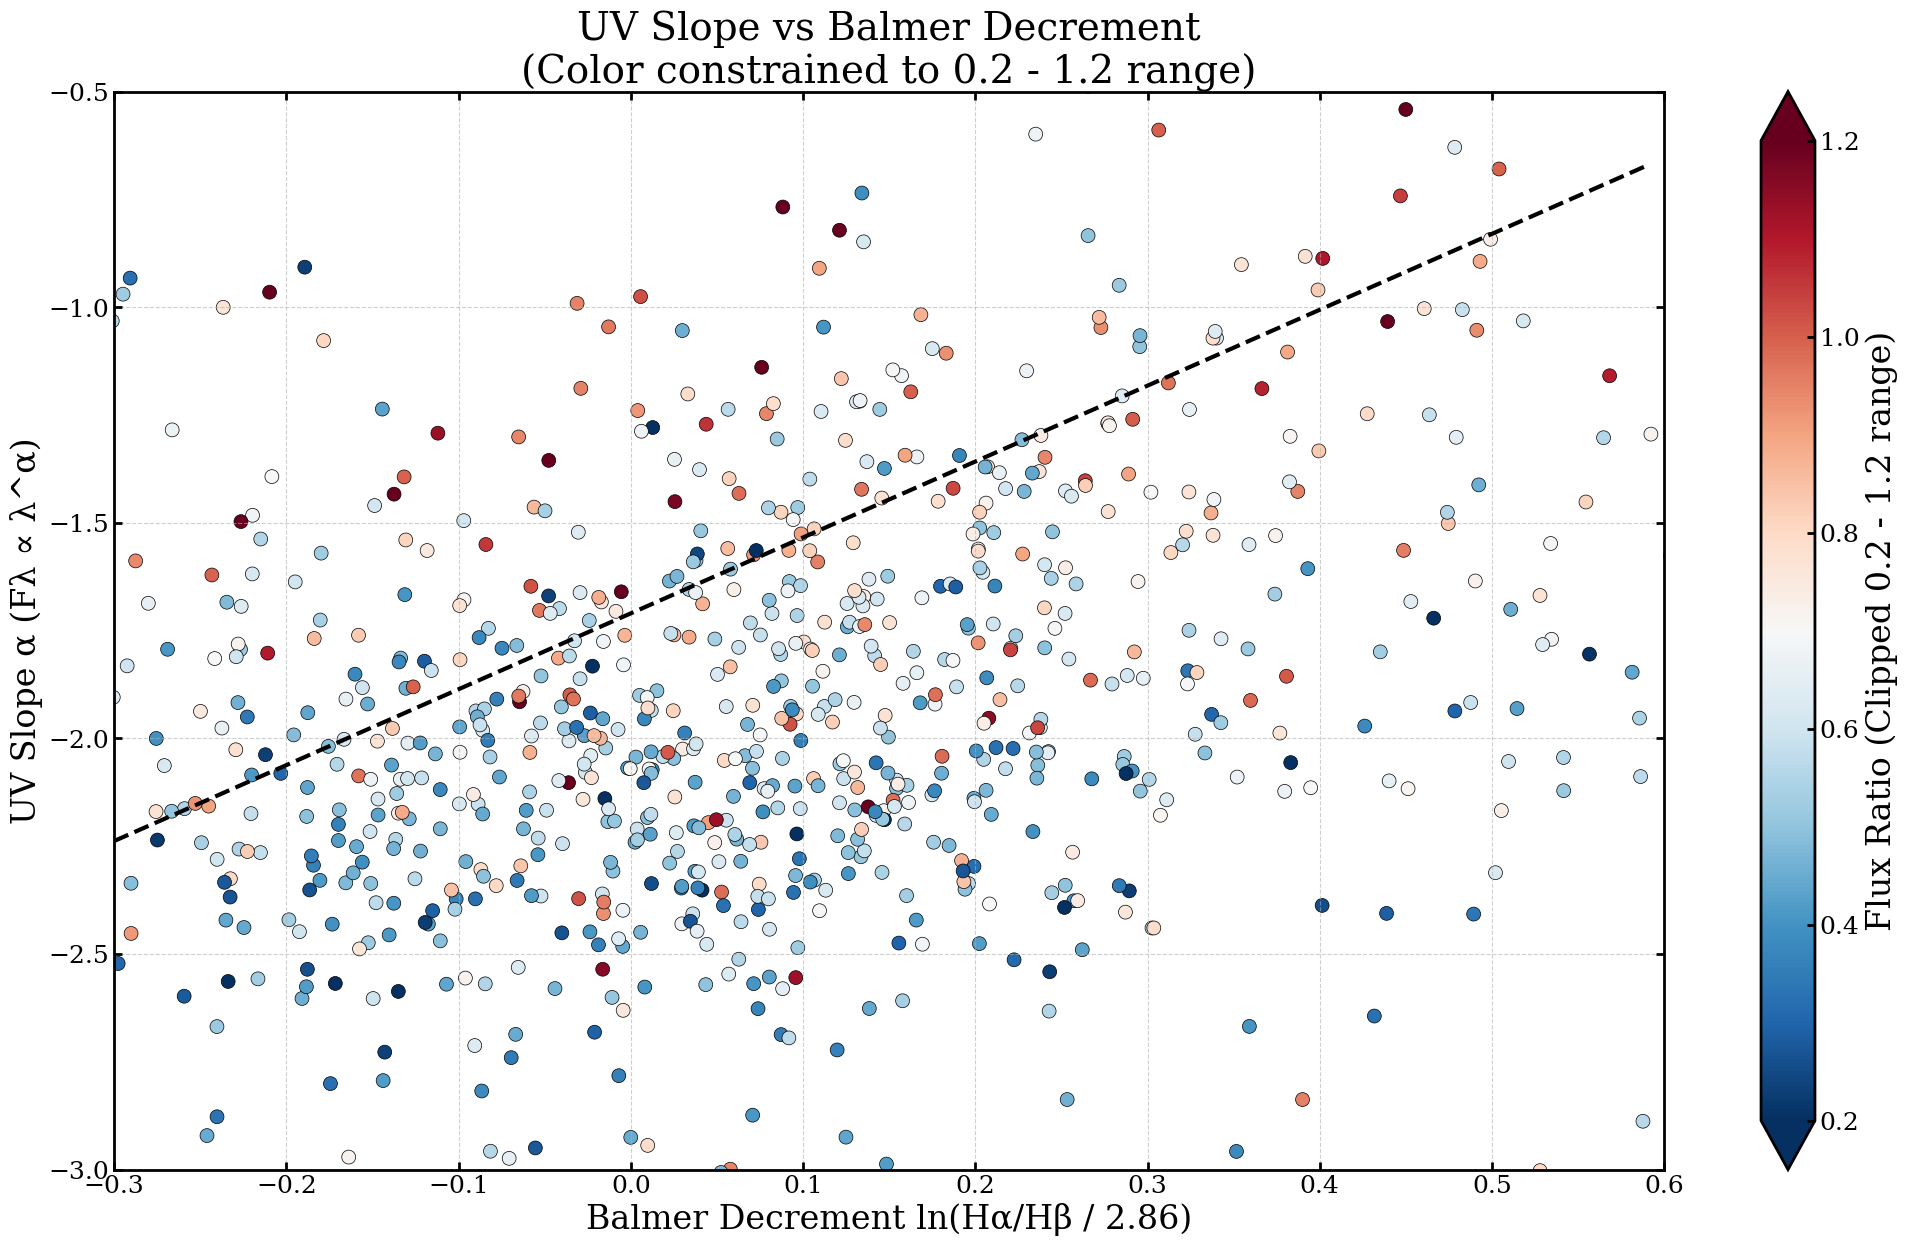

In [5]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=Dn_index_list,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=0.2,       # <--- 强制颜色映射下限
                      vmax=1.2,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=1,
                      edgecolor='k',
                      linewidth=0.5)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Flux Ratio (Clipped 0.2 - 1.2 range)')
plt.plot(np.arange(-0.3,0.6,0.01),Calzetti_beta(np.arange(-0.3,0.6,0.01)), color='black', linestyle='--', label='Calzetti et al. (1994) Relation', linewidth=3)

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 0.2 - 1.2 range)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
# plt.savefig('UV_Slope_vs_Balmer_Decrement_No_Correction_Clipped_0.2_1.2.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [6]:
dn_index_conditions=np.array([[0,0.51],[0.51,0.72],[0.72,1.5]])

Text(0.5, 1.0, 'Corrected Flux Ratio Distribution of Sample Galaxies')

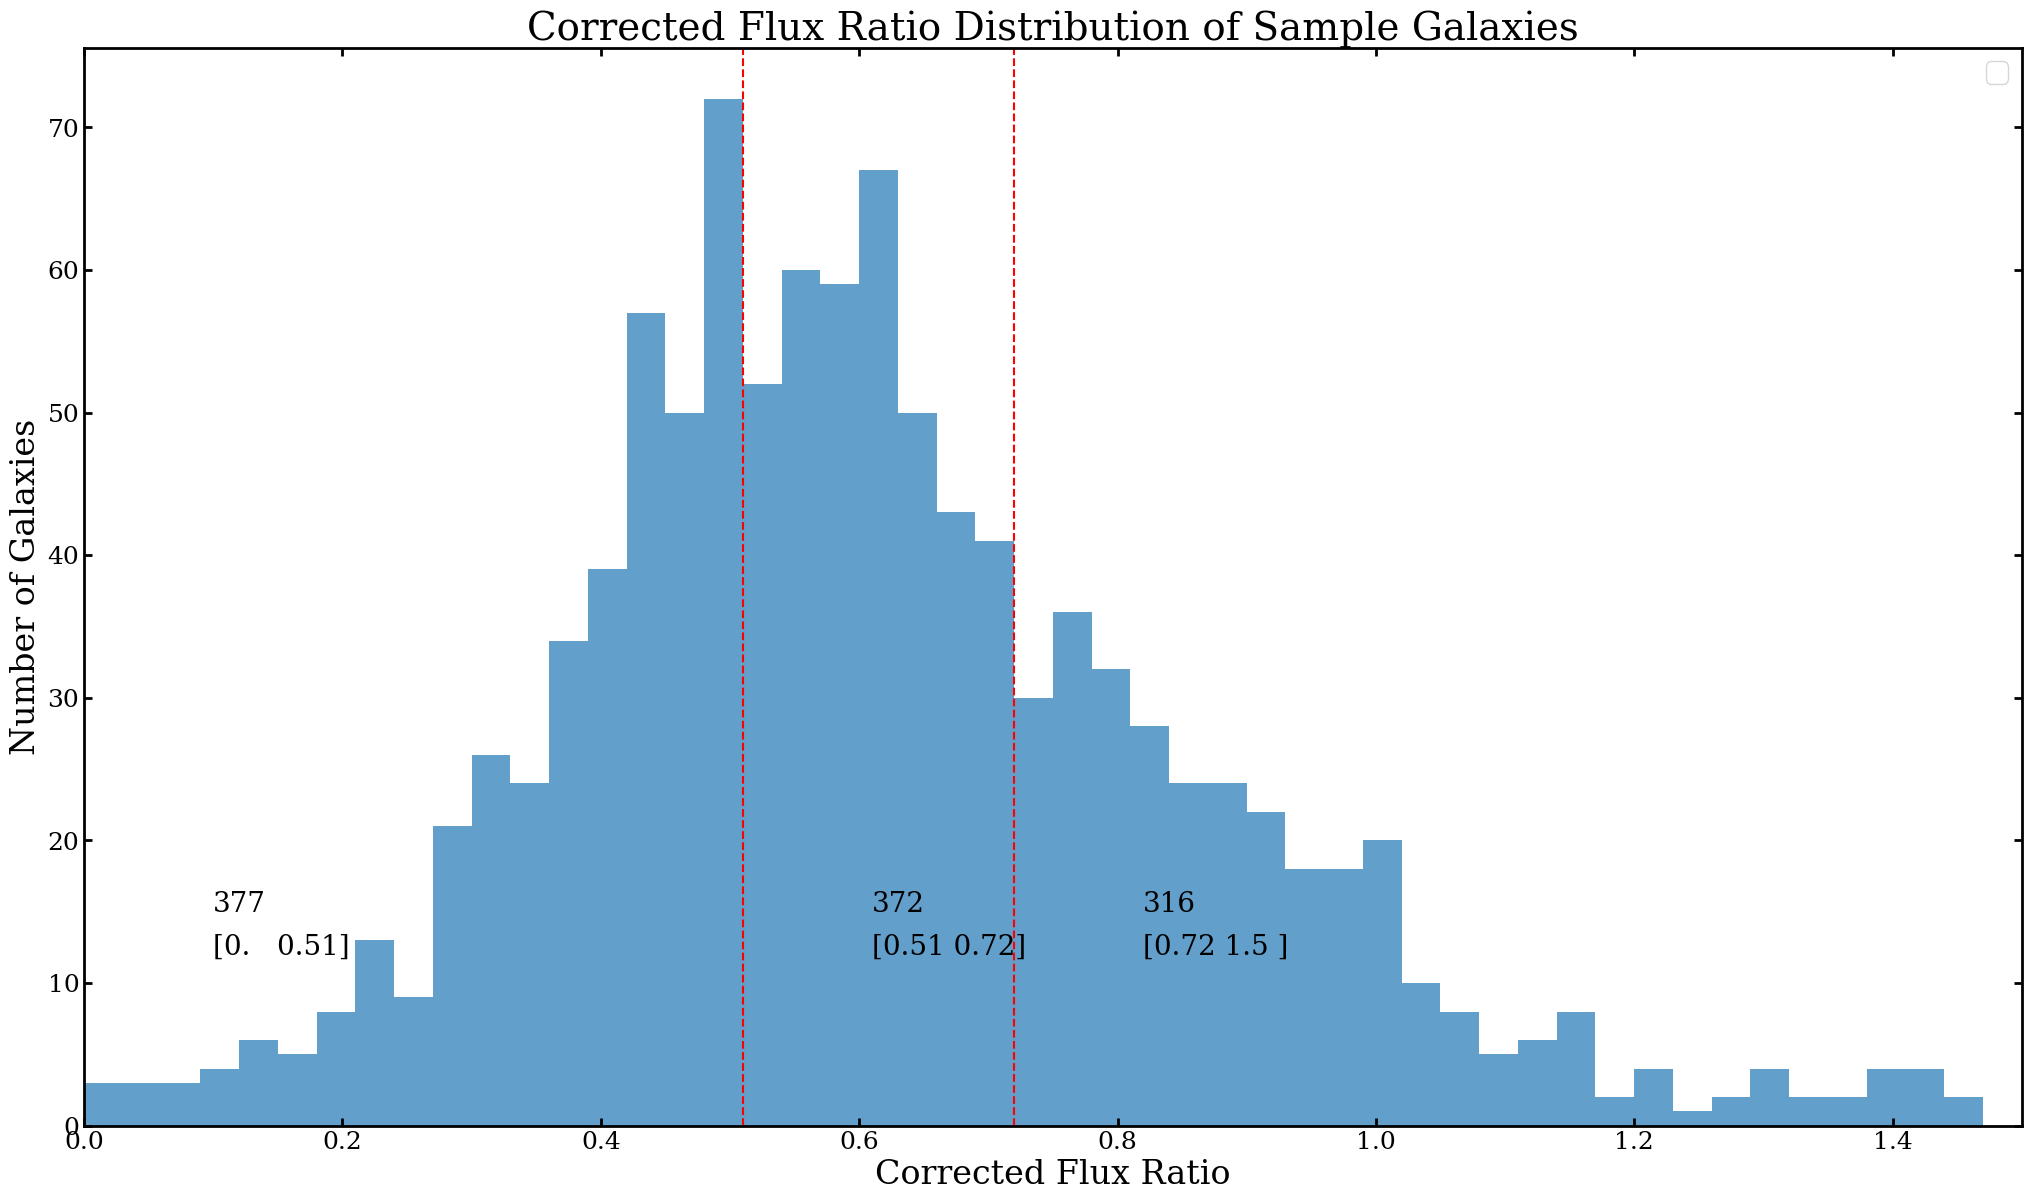

In [7]:
fig, ax=plt.subplots(figsize=(25,14))

ax.hist(Corrected_Flux_Ratio, bins=50,range=(0,1.5), alpha=0.7)
ax.set_xlabel('Corrected Flux Ratio',fontsize=24)
ax.set_ylabel('Number of Galaxies',fontsize=24)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.legend(fontsize=20, loc='best')
ax.set_xlim(0,1.5)
for bin_edge in dn_index_conditions:
    ax.axvline(bin_edge[0], color='r', linestyle='dashed')
    ax.text(bin_edge[0]+0.1, 15, f'{np.sum((Corrected_Flux_Ratio >= bin_edge[0]) & (Corrected_Flux_Ratio < bin_edge[1]))}', color='k', fontsize=20)
    ax.text(bin_edge[0]+0.1, 12, f'{bin_edge}', color='k', fontsize=20)
ax.set_title('Corrected Flux Ratio Distribution of Sample Galaxies', fontsize=28)

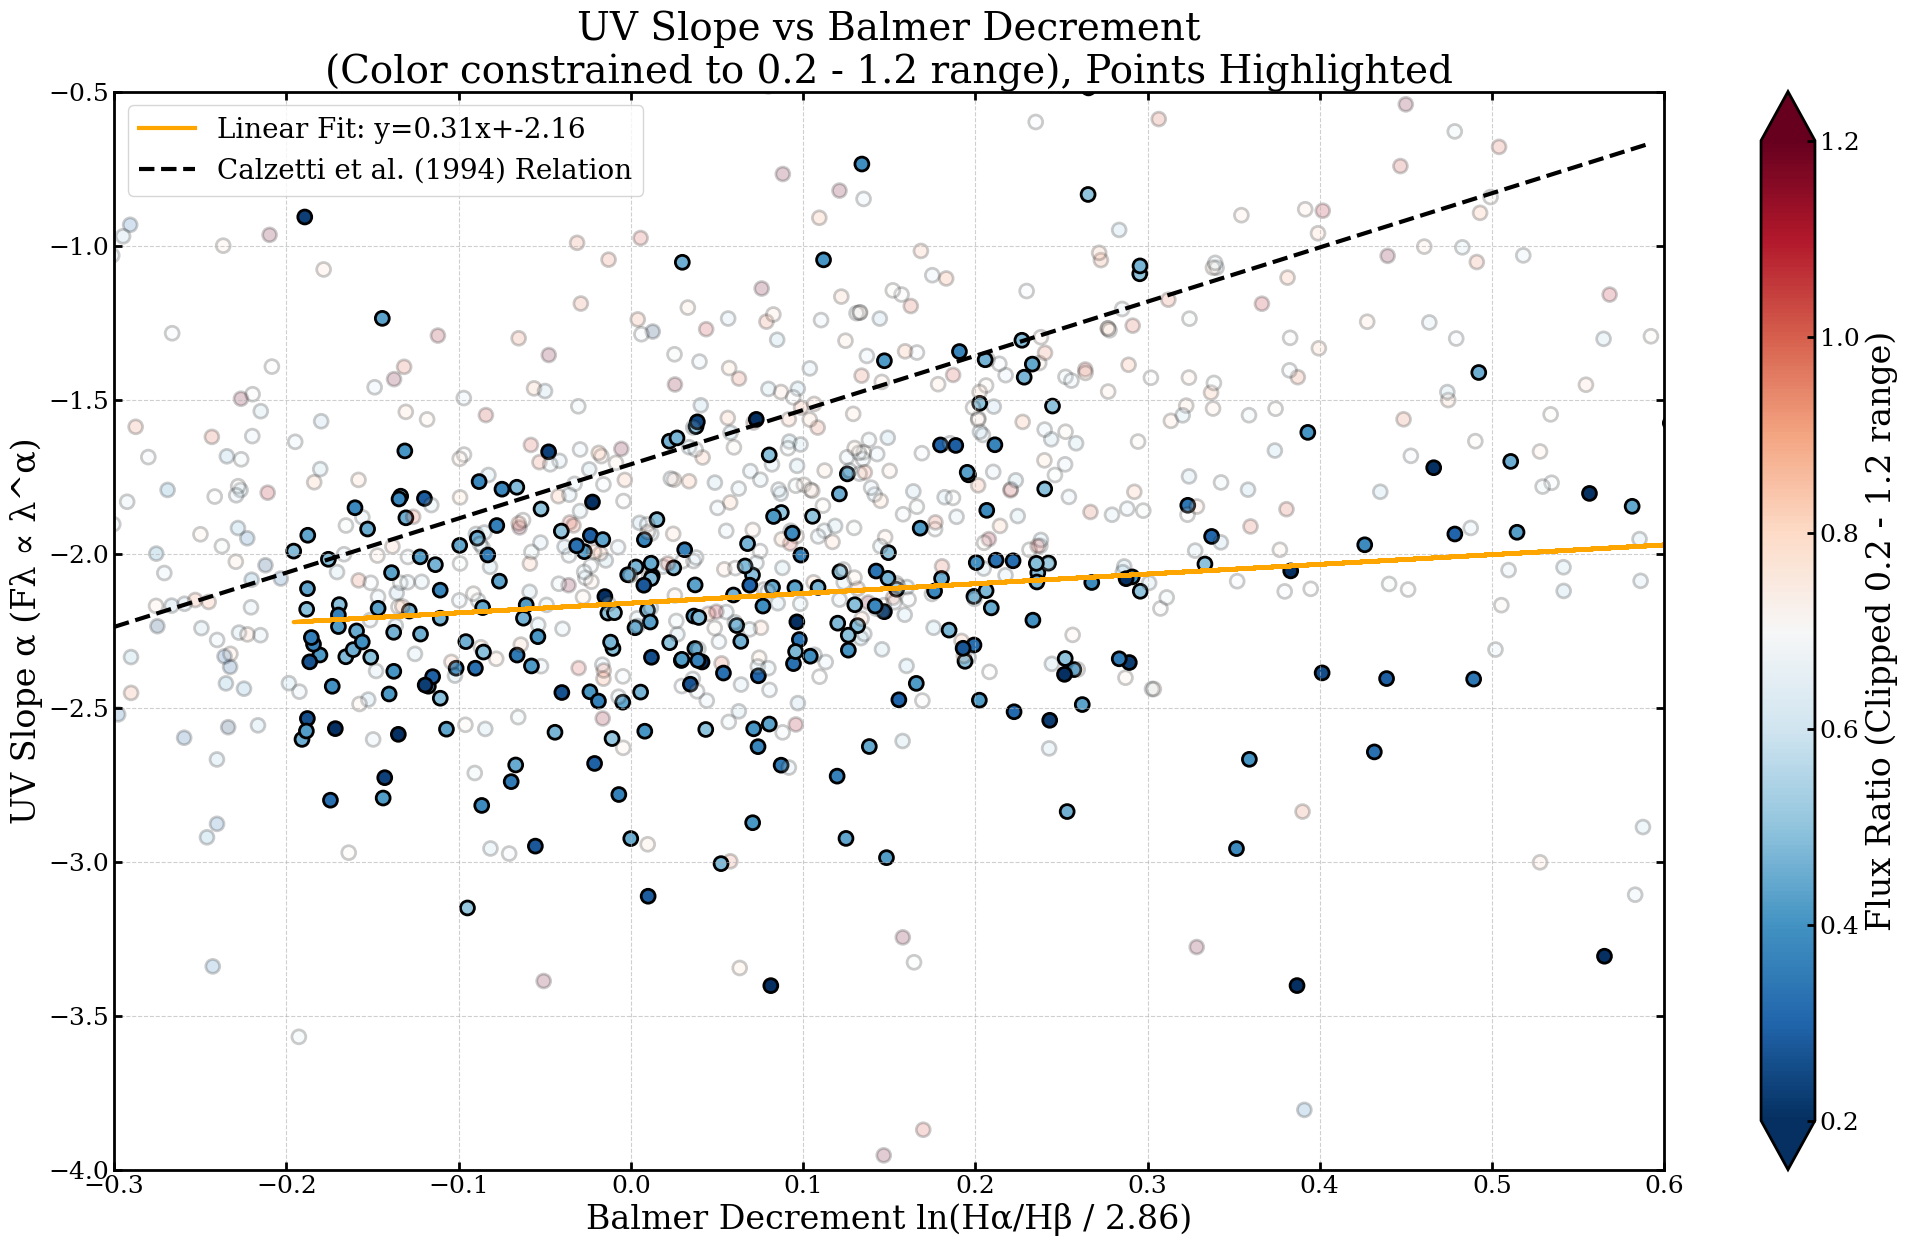

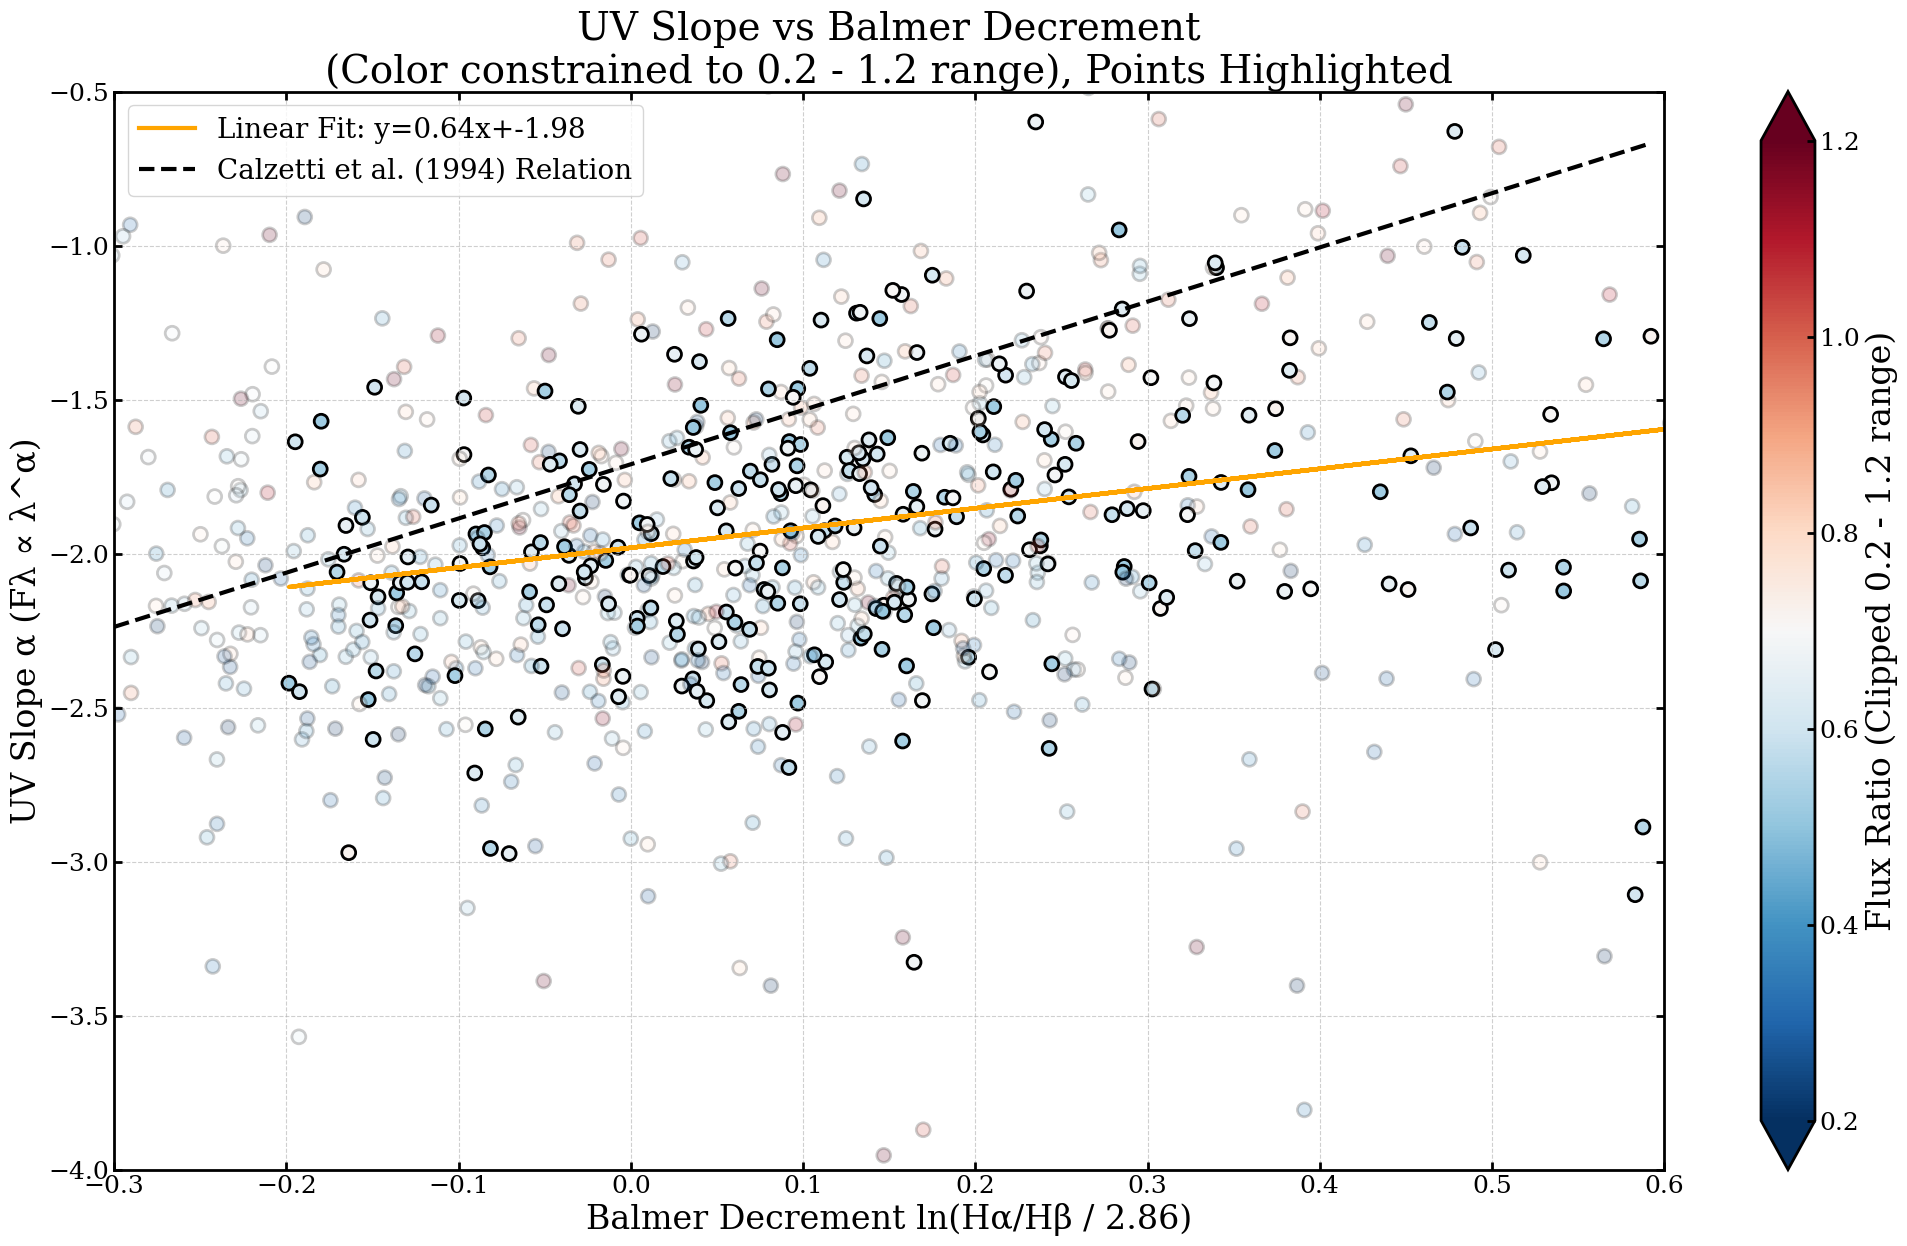

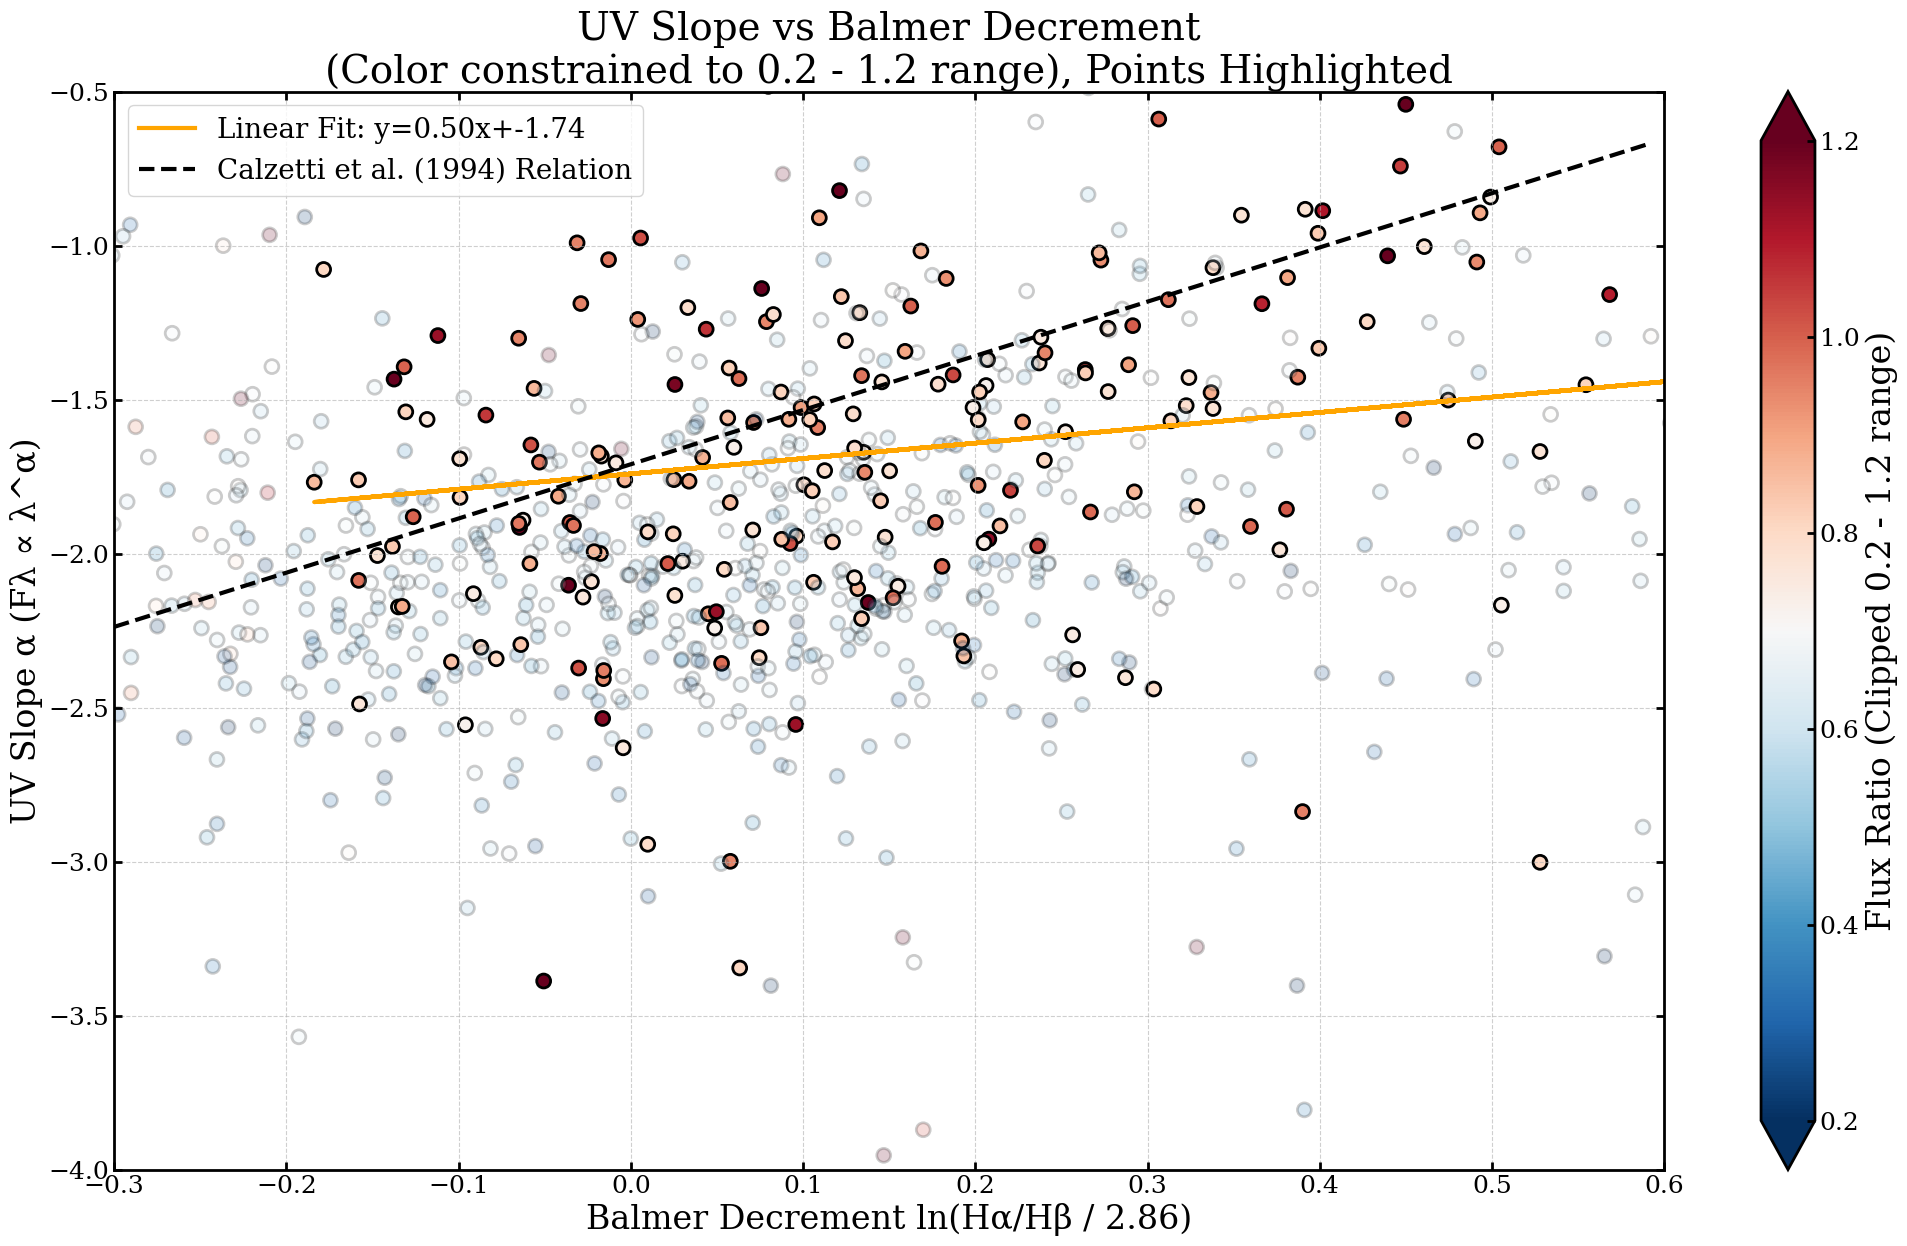

In [12]:


for i in range(len(dn_index_conditions)):
    bin_mask = (Corrected_Flux_Ratio >= dn_index_conditions[i][0]) & (Corrected_Flux_Ratio < dn_index_conditions[i][1])
    mask_alpha=1
    non_mask_alpha=0.2

    absolute_value_condition=(uv_slope_array>-3.5)&(uv_slope_array<0)
    balmer_decrement_condition=(balmer_decrement_array>-0.2)
    bin_mask=bin_mask & np.where(balmer_decrement_condition, True, False)
    bin_mask=bin_mask & np.where(absolute_value_condition, True, False)

    percentile=np.percentile(Corrected_Flux_Ratio[bin_mask], [2.5,97.5])
    # bin_mask=bin_mask & np.where((Corrected_Flux_Ratio>=percentile[0]) & (Corrected_Flux_Ratio<=percentile[1]), True, False)

    alpha_array=np.where(bin_mask, mask_alpha, non_mask_alpha)
    plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
    scatter = plt.scatter(balmer_decrement_array,
                            uv_slope_array,
                        c=Corrected_Flux_Ratio,
                        cmap='RdBu_r',  # 蓝(小) -> 红(大)
                        vmin=0.2,       # <--- 强制颜色映射下限
                        vmax=1.2,       # <--- 强制颜色映射上限
                        s=100,
                        alpha=np.array(alpha_array),
                        edgecolor='k',
                        linewidth=2)

    popt, pcov = curve_fit(Linear_relation, balmer_decrement_array[bin_mask], uv_slope_array[bin_mask])
    plt.plot(balmer_decrement_array[bin_mask], Linear_relation(balmer_decrement_array[bin_mask], *popt), color='orange', linestyle='-', label=f'Linear Fit: y={popt[0]:.2f}x+{popt[1]:.2f}', linewidth=3)

    # 关键修改：添加 extend='both'
    # 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
    cbar = plt.colorbar(scatter, extend='both')
    cbar.set_label('Flux Ratio (Clipped 0.2 - 1.2 range)')
    plt.plot(np.arange(-0.3,0.6,0.01), Calzetti_beta(np.arange(-0.3,0.6,0.01)), color='black', linestyle='--', label='Calzetti et al. (1994) Relation',linewidth=3)

    plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
    plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
    plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 0.2 - 1.2 range), Points Highlighted')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(-0.3,0.6)
    plt.ylim(-4,-0.5)
    plt.legend(fontsize=20, loc='best')
    # plt.savefig('Bluest_Points.pdf', bbox_inches='tight', dpi=300)
    plt.show()

In [13]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_decrement_list=[]
balmer_decrement_err_list=[]

redshift_conditions=np.array([[3,3.6],[3.6,4.4],[4.4,5.7],[5.7,7.2]])
def redshift_condition_func(z,redshift_conditions=redshift_conditions):
    for i, condition in enumerate(redshift_conditions):
        if condition[0]<=z<condition[1]:
            return i

color=['b','g','r','c','m','y','k']
colors_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    continuum_dict=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
    lines_dict=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

    balmer_ratio_uncertainty=FL.BalmerDecrementUncertainty(lines_dict['halpha_flux'], lines_dict['halpha_flux_err'], lines_dict['hbeta_flux'], lines_dict['hbeta_flux_err'])

    balmer_ratio=lines_dict['halpha_flux']/lines_dict['hbeta_flux']
    balmer_ratio_snr=balmer_ratio/balmer_ratio_uncertainty

    uv_slope=continuum_dict['exponent']
    uv_slope_err=continuum_dict['exponent_error']

    balmer_decrement=np.log(balmer_ratio/2.86)
    redshift_bin_index=redshift_condition_func(catalog['determined_redshift'])
    colors_list.append(color[redshift_bin_index])

    uv_slope_list.append(uv_slope)
    uv_slope_err_list.append(uv_slope_err)
    balmer_decrement_list.append(balmer_decrement)
    balmer_decrement_err_list.append(balmer_ratio_uncertainty / balmer_ratio)

balmer_decrement_array=np.array(balmer_decrement_list)
balmer_decrement_uncertainty_array=np.array(balmer_decrement_err_list)
uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)

In [17]:
group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

def dn_condition_func(dn_index):
    for i, (low, high) in enumerate(dn_index_conditions):
        if low < dn_index <= high:
            return i
    return 6

In [21]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

Spectrum index 7 has invalid normalization factor. Skipping.


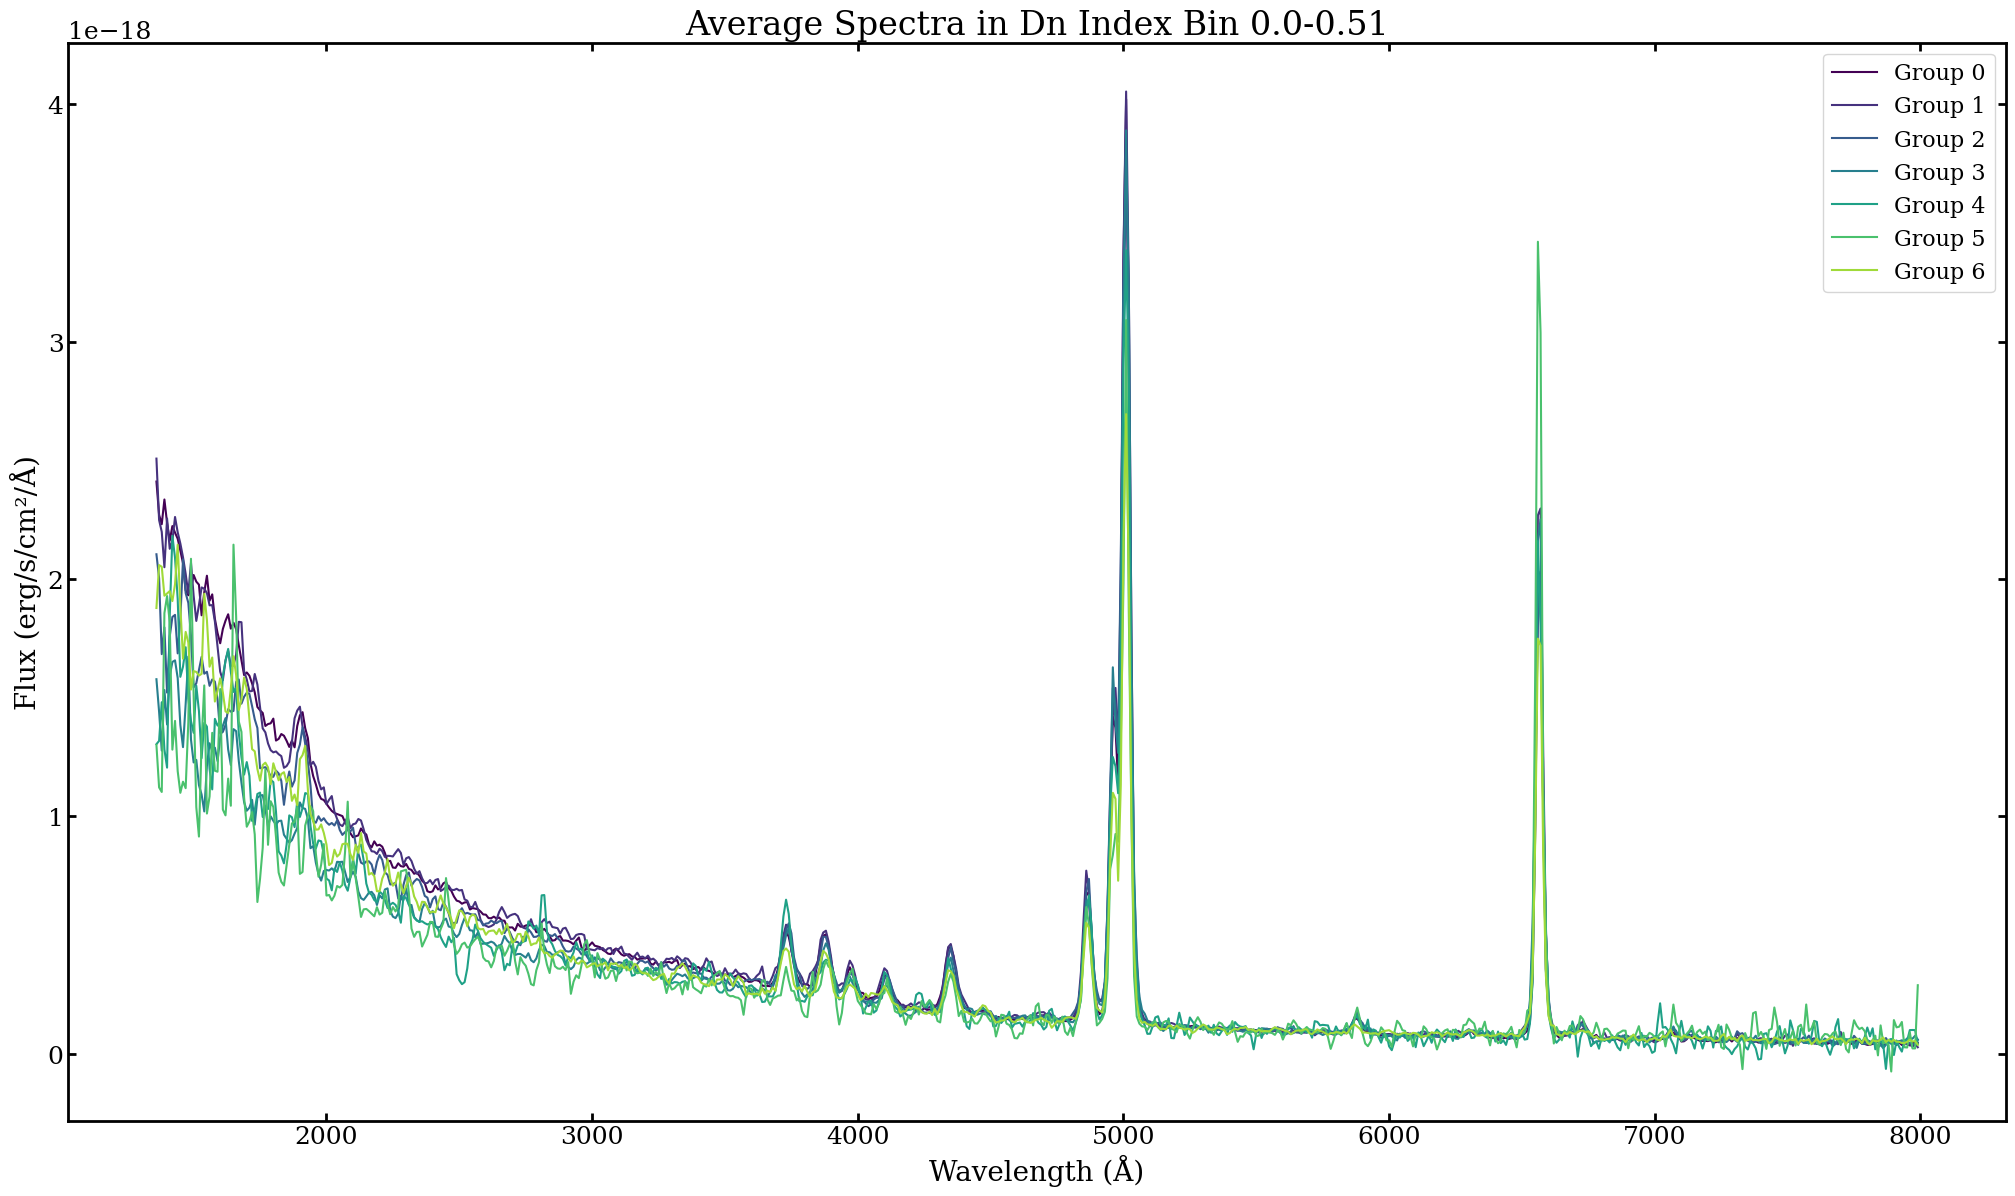

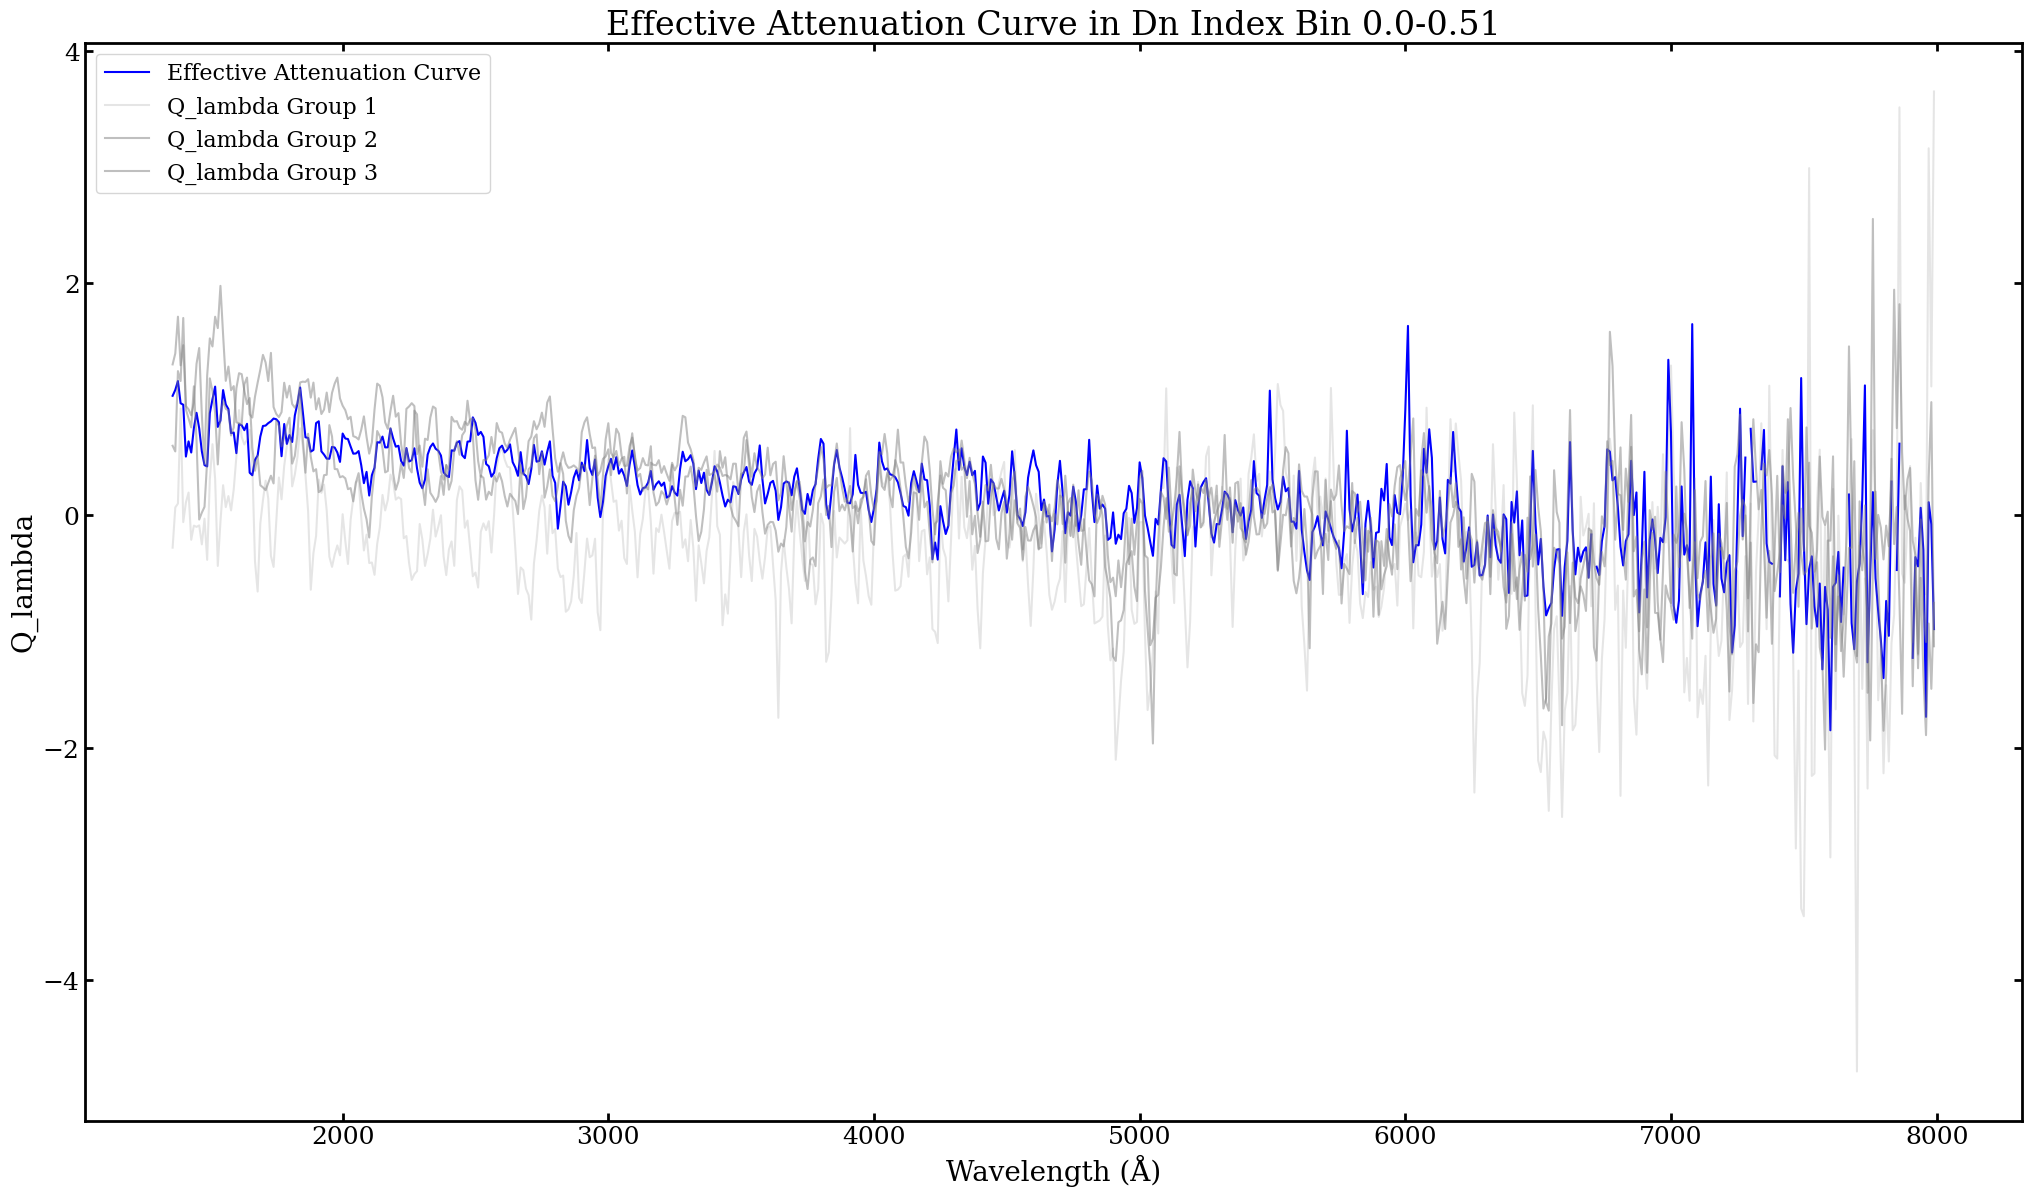

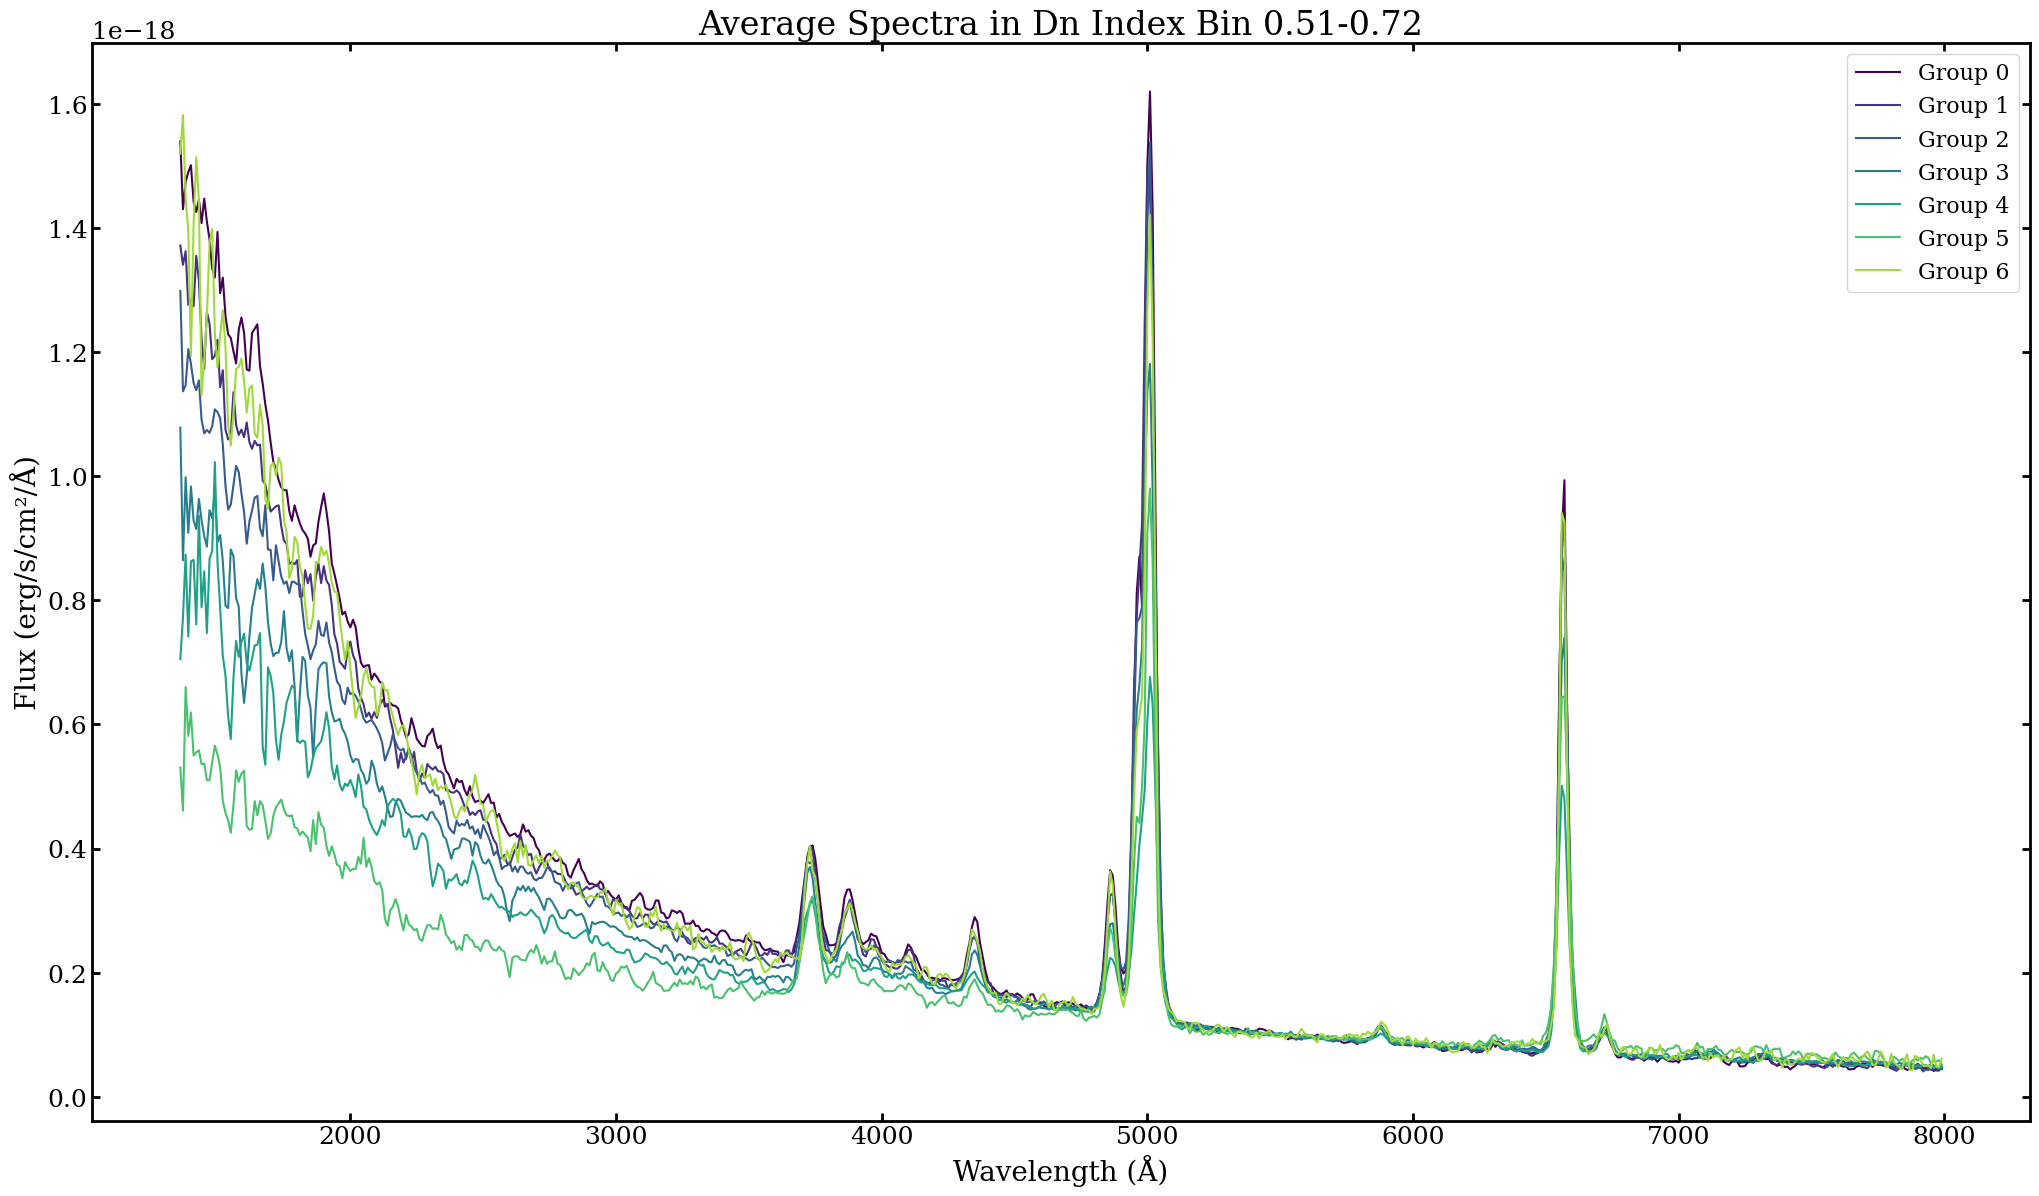

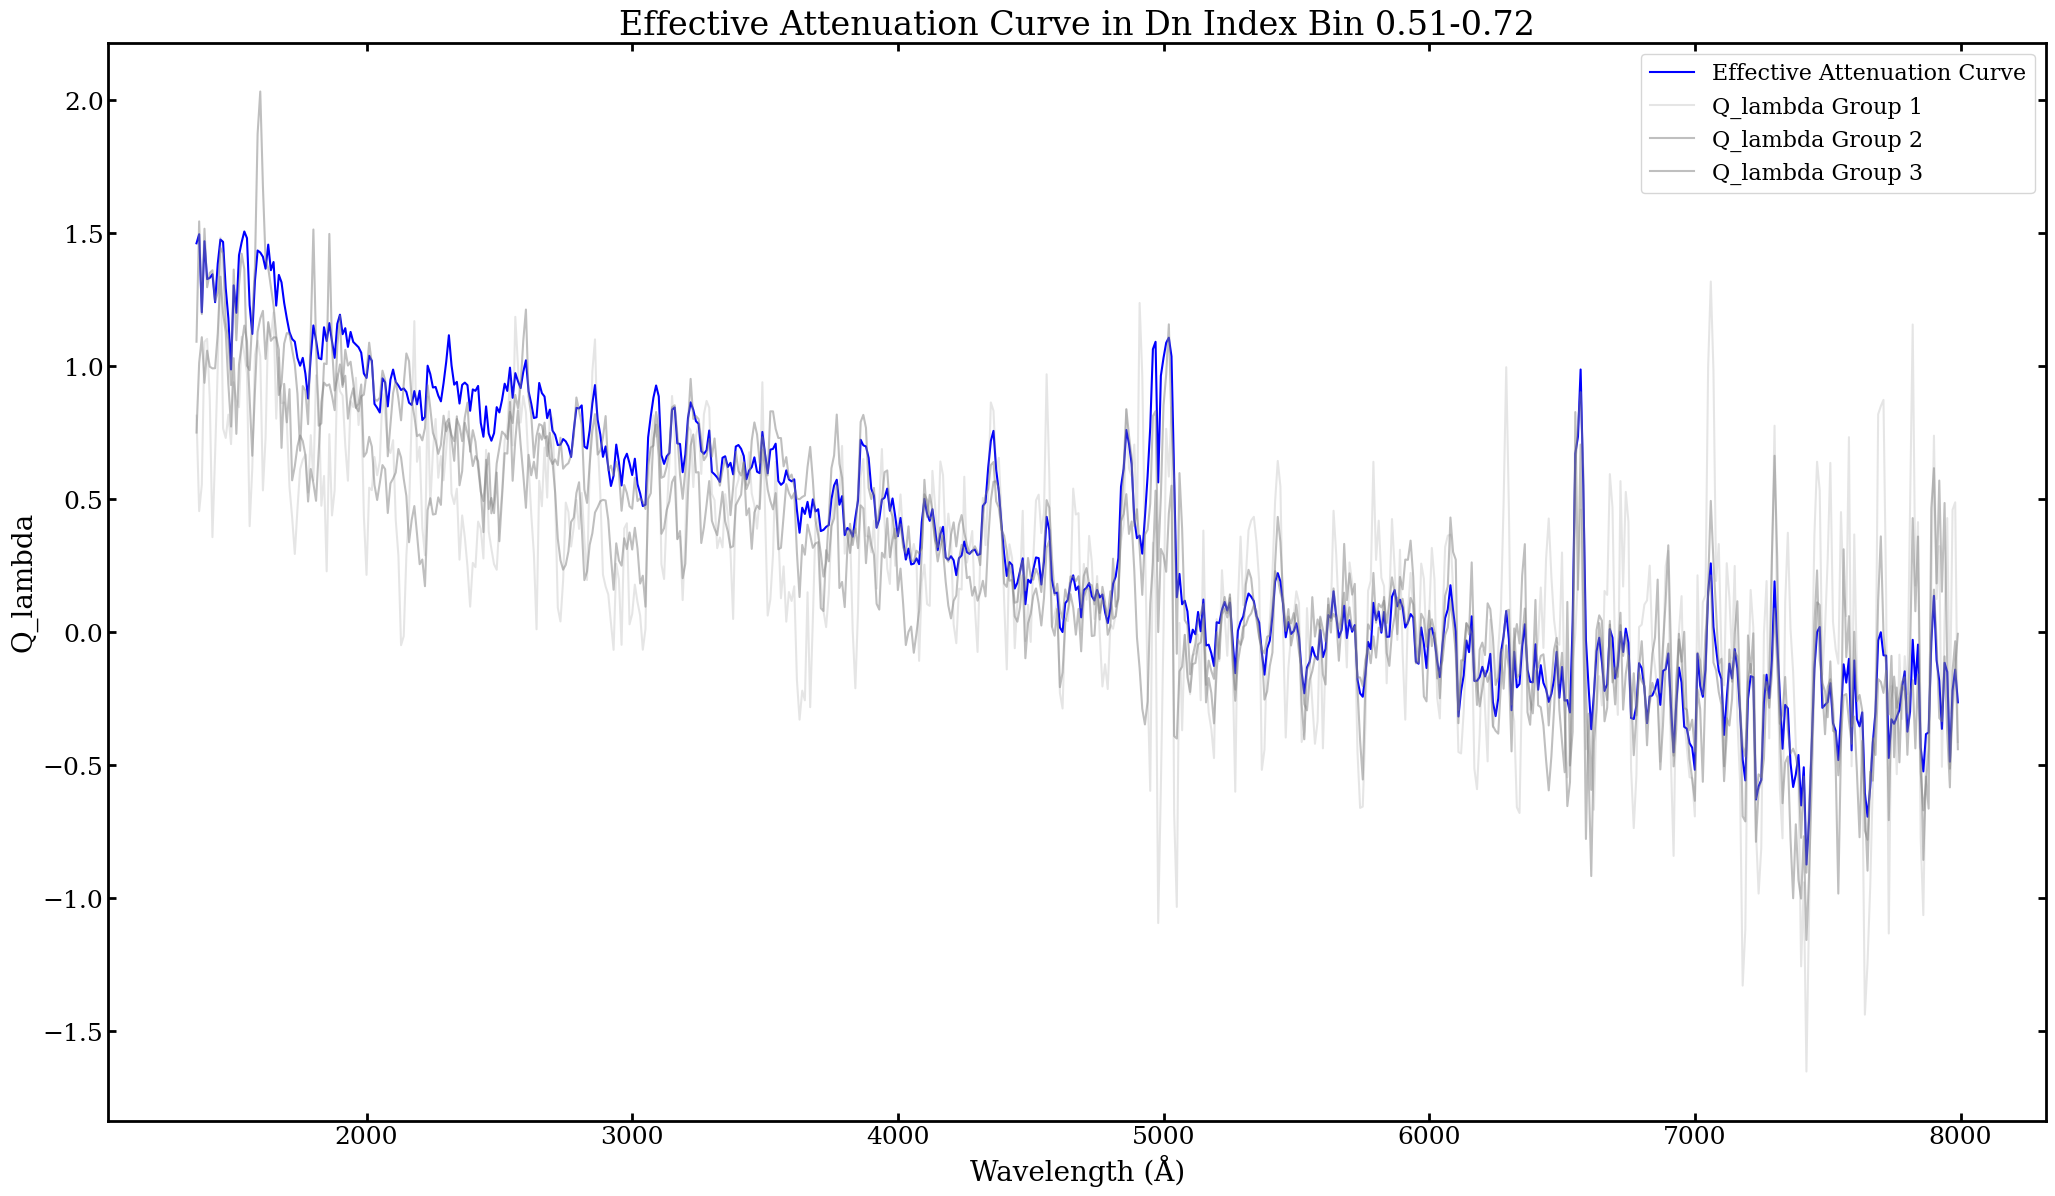

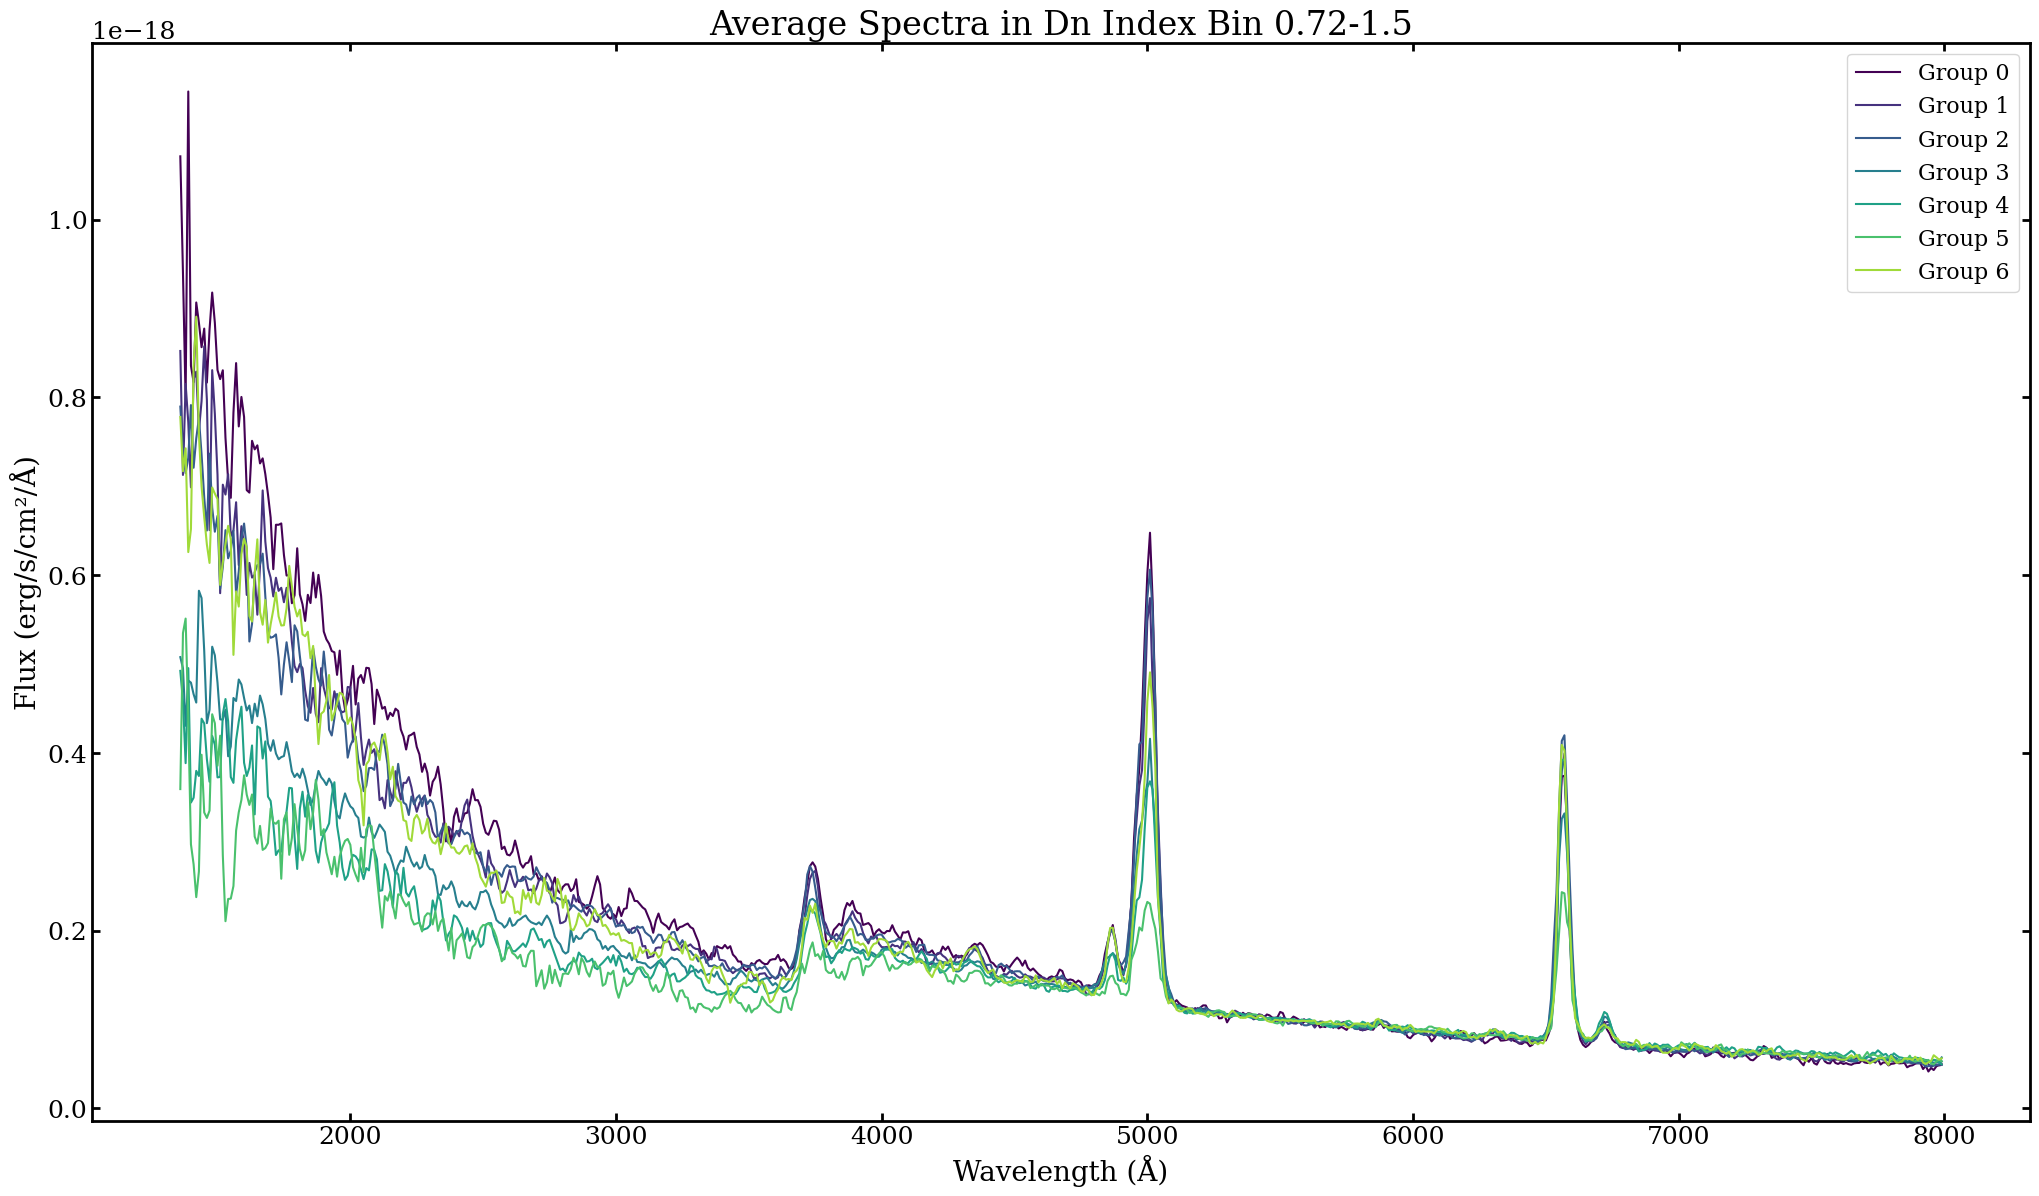

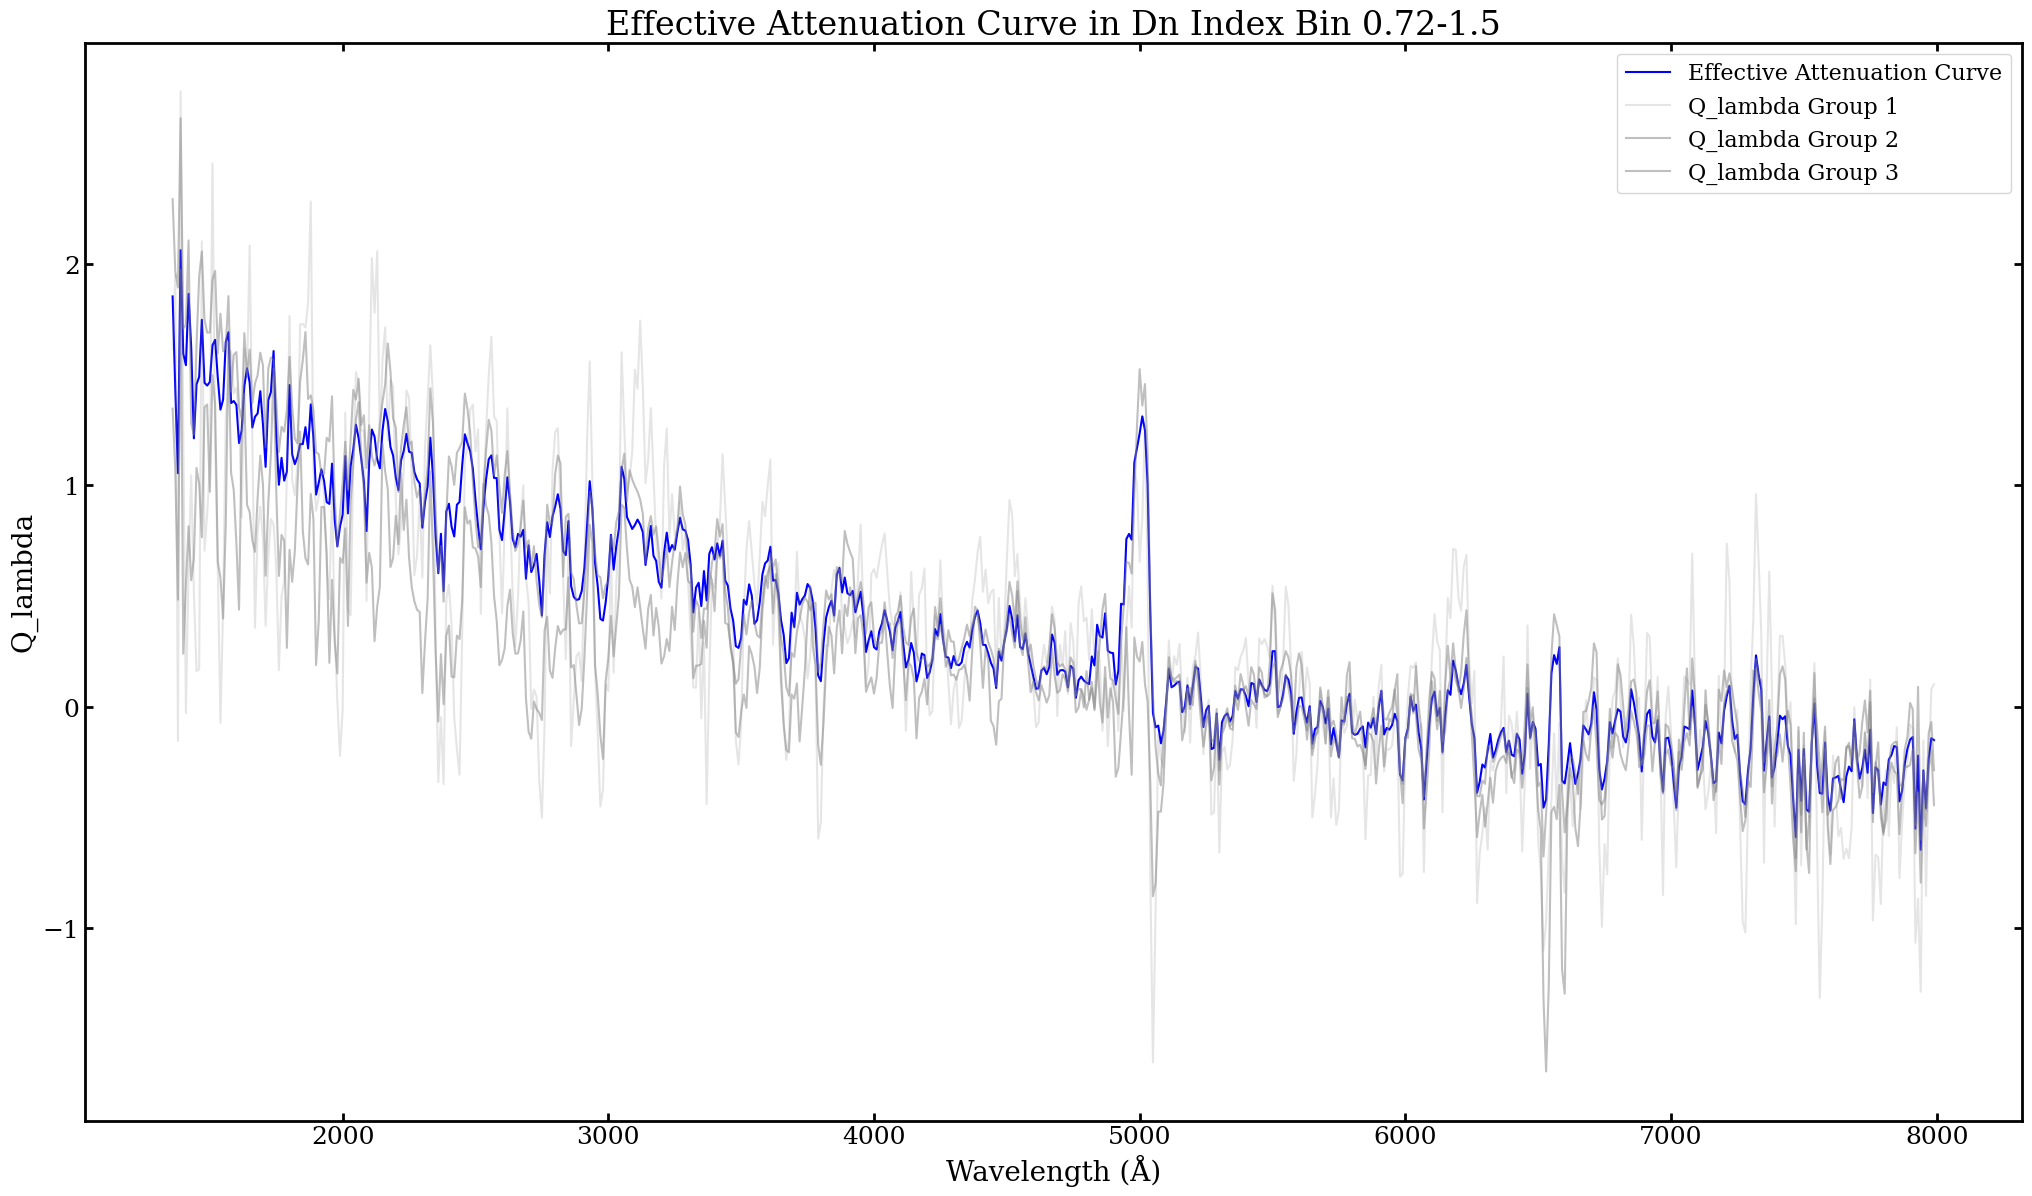

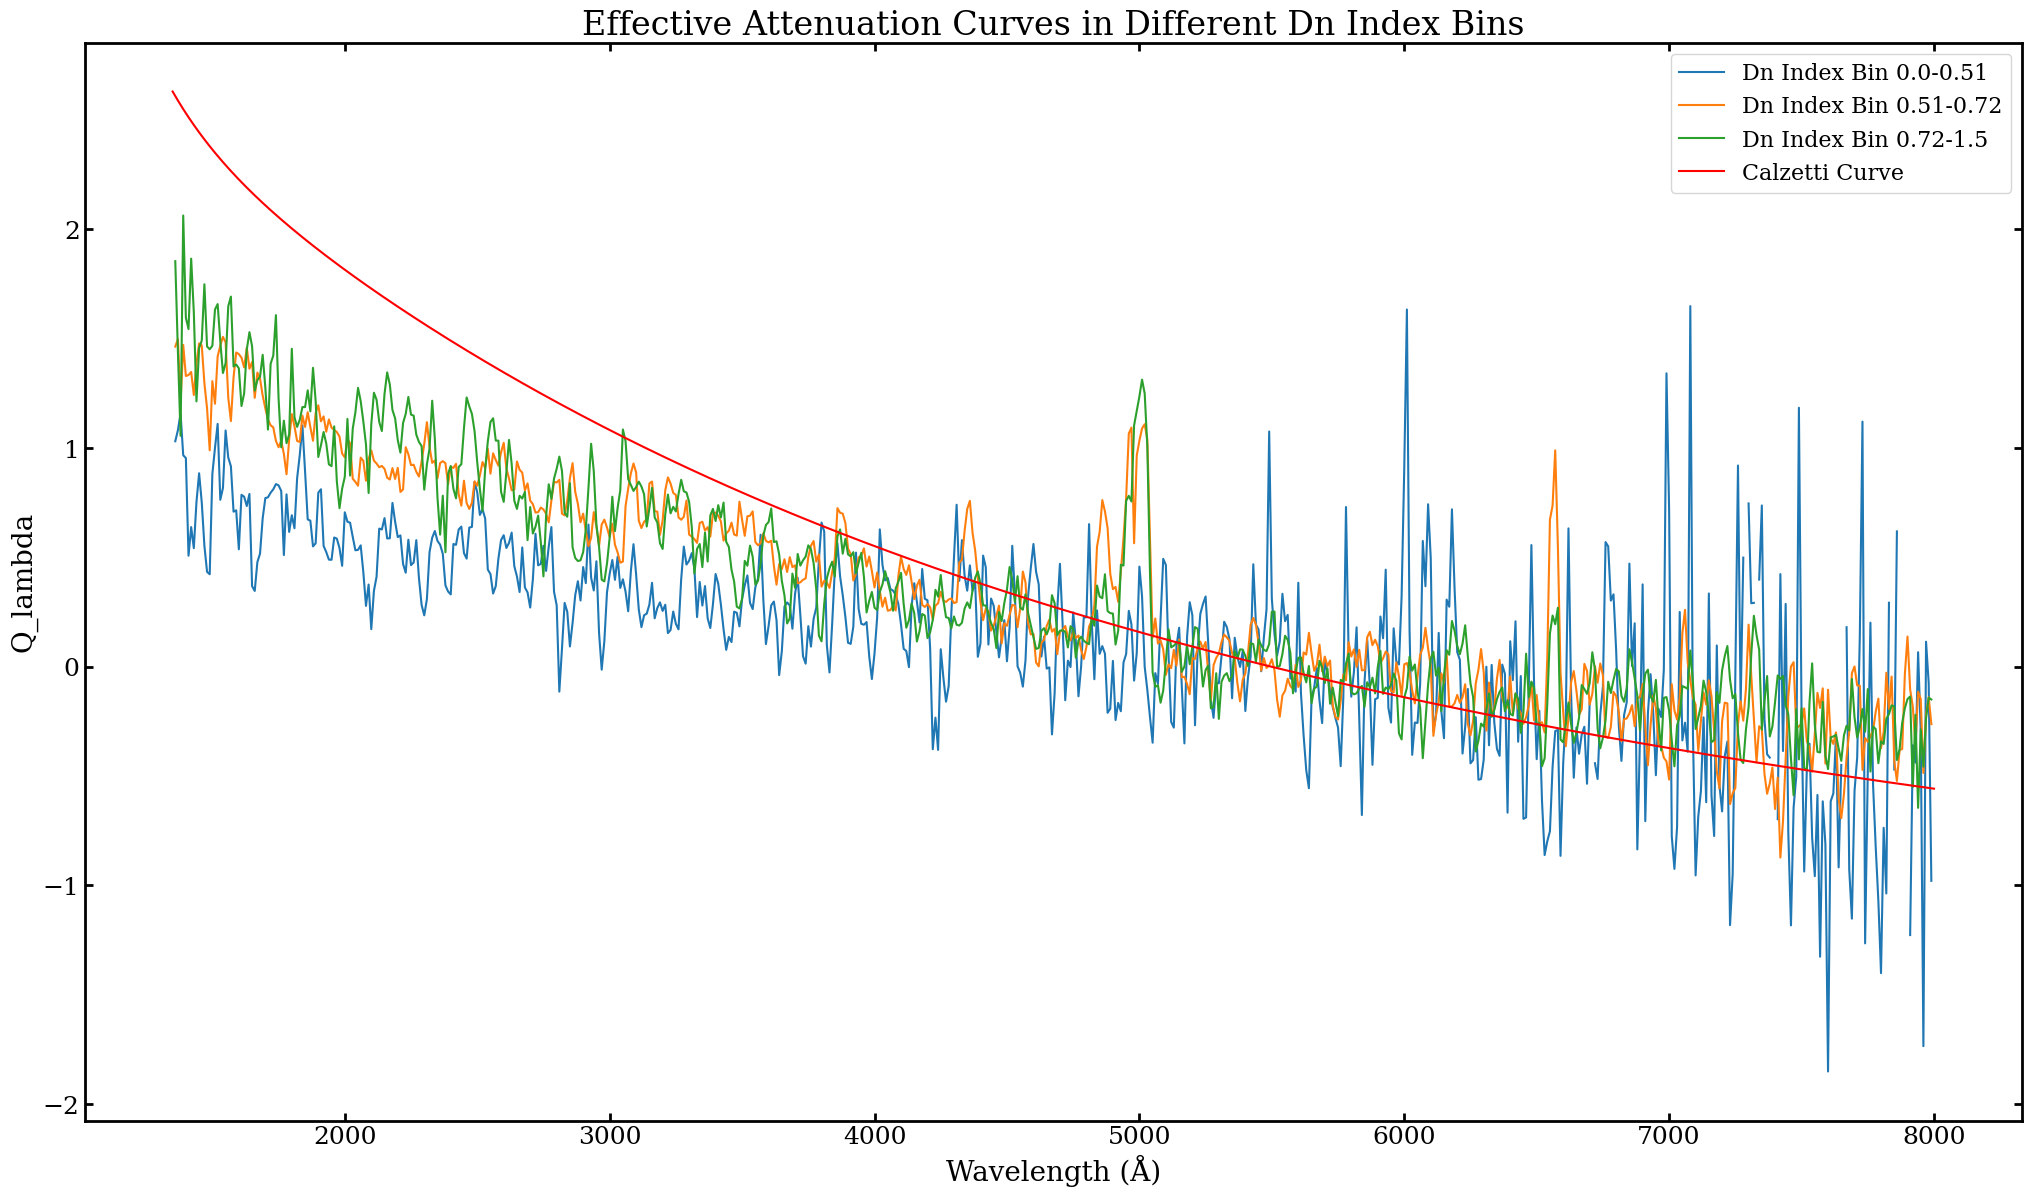

In [24]:
effective_attenuation_curve_list=[]

for dn_bin_index in range(len(dn_index_conditions)):

    group0_averager=FL.SpectrumAverager()
    group1_averager=FL.SpectrumAverager()
    group2_averager=FL.SpectrumAverager()
    group3_averager=FL.SpectrumAverager()
    group4_averager=FL.SpectrumAverager()
    group5_averager=FL.SpectrumAverager()
    group6_averager=FL.SpectrumAverager()


    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        dn_index=catalog['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['red_flux_density']/catalog['dust_curve_parameters']['Corrected_Flux_Density_Measurements']['blue_flux_density']

        dn_bin_id=dn_condition_func(dn_index)
        if dn_bin_id != dn_bin_index:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index==-1:
            continue

        averager_to_use='group'+str(group_index)+'_averager'
        globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)
    invalid_averager=np.zeros(7, dtype=bool)
    for i in range(7):
        try:
            averager_to_use='group'+str(i)+'_averager'
            globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
            globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
            globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5250,5750),target_flux=1e-19)
            globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
            # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0)
            invalid_averager[i]=False

        except Exception as e:
            print(f'Warning: Unable to compute average spectrum for Redshift Bin {redshift_conditions[redshift_bin_index][0]}-{redshift_conditions[redshift_bin_index][1]}, Group {i}. Skipping this group.')
            invalid_averager[i]=True

    group_decrement_list=[]

    for i in range(6):
        decrement_list=[]

        for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
            if not catalog['sample_flag']:
                continue

            uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
            halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
            hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
            balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
            group_index=group_condition_func(balmer_decrement)
            if group_index!=i:
                continue
            if group_index==-1:
                continue

            decrement_list.append(balmer_decrement)

        group_decrement_list.append(np.mean(decrement_list))

    model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
    tau_lambda_list=[]
    Q_lambda_list=[]

    for i in range(1,6):
        if invalid_averager[i]:
            Q_lambda_list.append(np.zeros_like(group0_averager.common_wavelength))
            continue
        averager_to_use='group'+str(i)+'_averager'
        tau_lambda_list=[]
        groupi_averager=globals()[averager_to_use]
        tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
        tau_lambda_list.append(tau_lambda)
        Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
        Q_lambda_list.append(Q_lambda)

    fig, ax=plt.subplots(figsize=(25,14))
    colors=plt.cm.viridis(np.linspace(0,7))
    for i in range(7):
        if invalid_averager[i]:
            continue
        averager_to_use='group'+str(i)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
    ax.set_xlabel('Wavelength (Å)', fontsize=20)
    ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=20)
    ax.set_title(f'Average Spectra in Dn Index Bin {dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', fontsize=24)
    ax.legend(fontsize=16)
    plt.show()


    Q_lambda_array=np.array(Q_lambda_list)

    valid_weights = []
    for i in range(1,6):
        if not invalid_averager[i]:
            valid_weights.append(group_decrement_list[i]-group_decrement_list[0])

    effective_attenuation_curve=np.average(Q_lambda_array[~np.array(invalid_averager[1:-1])], axis=0, weights=valid_weights)
    fig, ax=plt.subplots(figsize=(25,14))
    averager=group1_averager
    ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
    for i in range(0,3):
        if invalid_averager[i+1]:
            continue
        Q_lambda=Q_lambda_list[i]
        averager_to_use='group'+str(i+1)+'_averager'
        averager=globals()[averager_to_use]
        ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))
    plt.xlabel('Wavelength (Å)', fontsize=20)
    plt.ylabel('Q_lambda', fontsize=20)
    plt.title('Effective Attenuation Curve in Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', fontsize=24)
    plt.legend(fontsize=16)
    plt.show()
    effective_attenuation_curve_list.append((averager.common_wavelength, effective_attenuation_curve))


colors=sns.color_palette( n_colors=len(dn_index_conditions))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))

for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[dn_bin_index]
    ax.plot(common_wavelength, effective_attenuation_curve, label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', color=colors[dn_bin_index])

ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Dn Index Bins', fontsize=24)
plt.legend(fontsize=16)
plt.show()

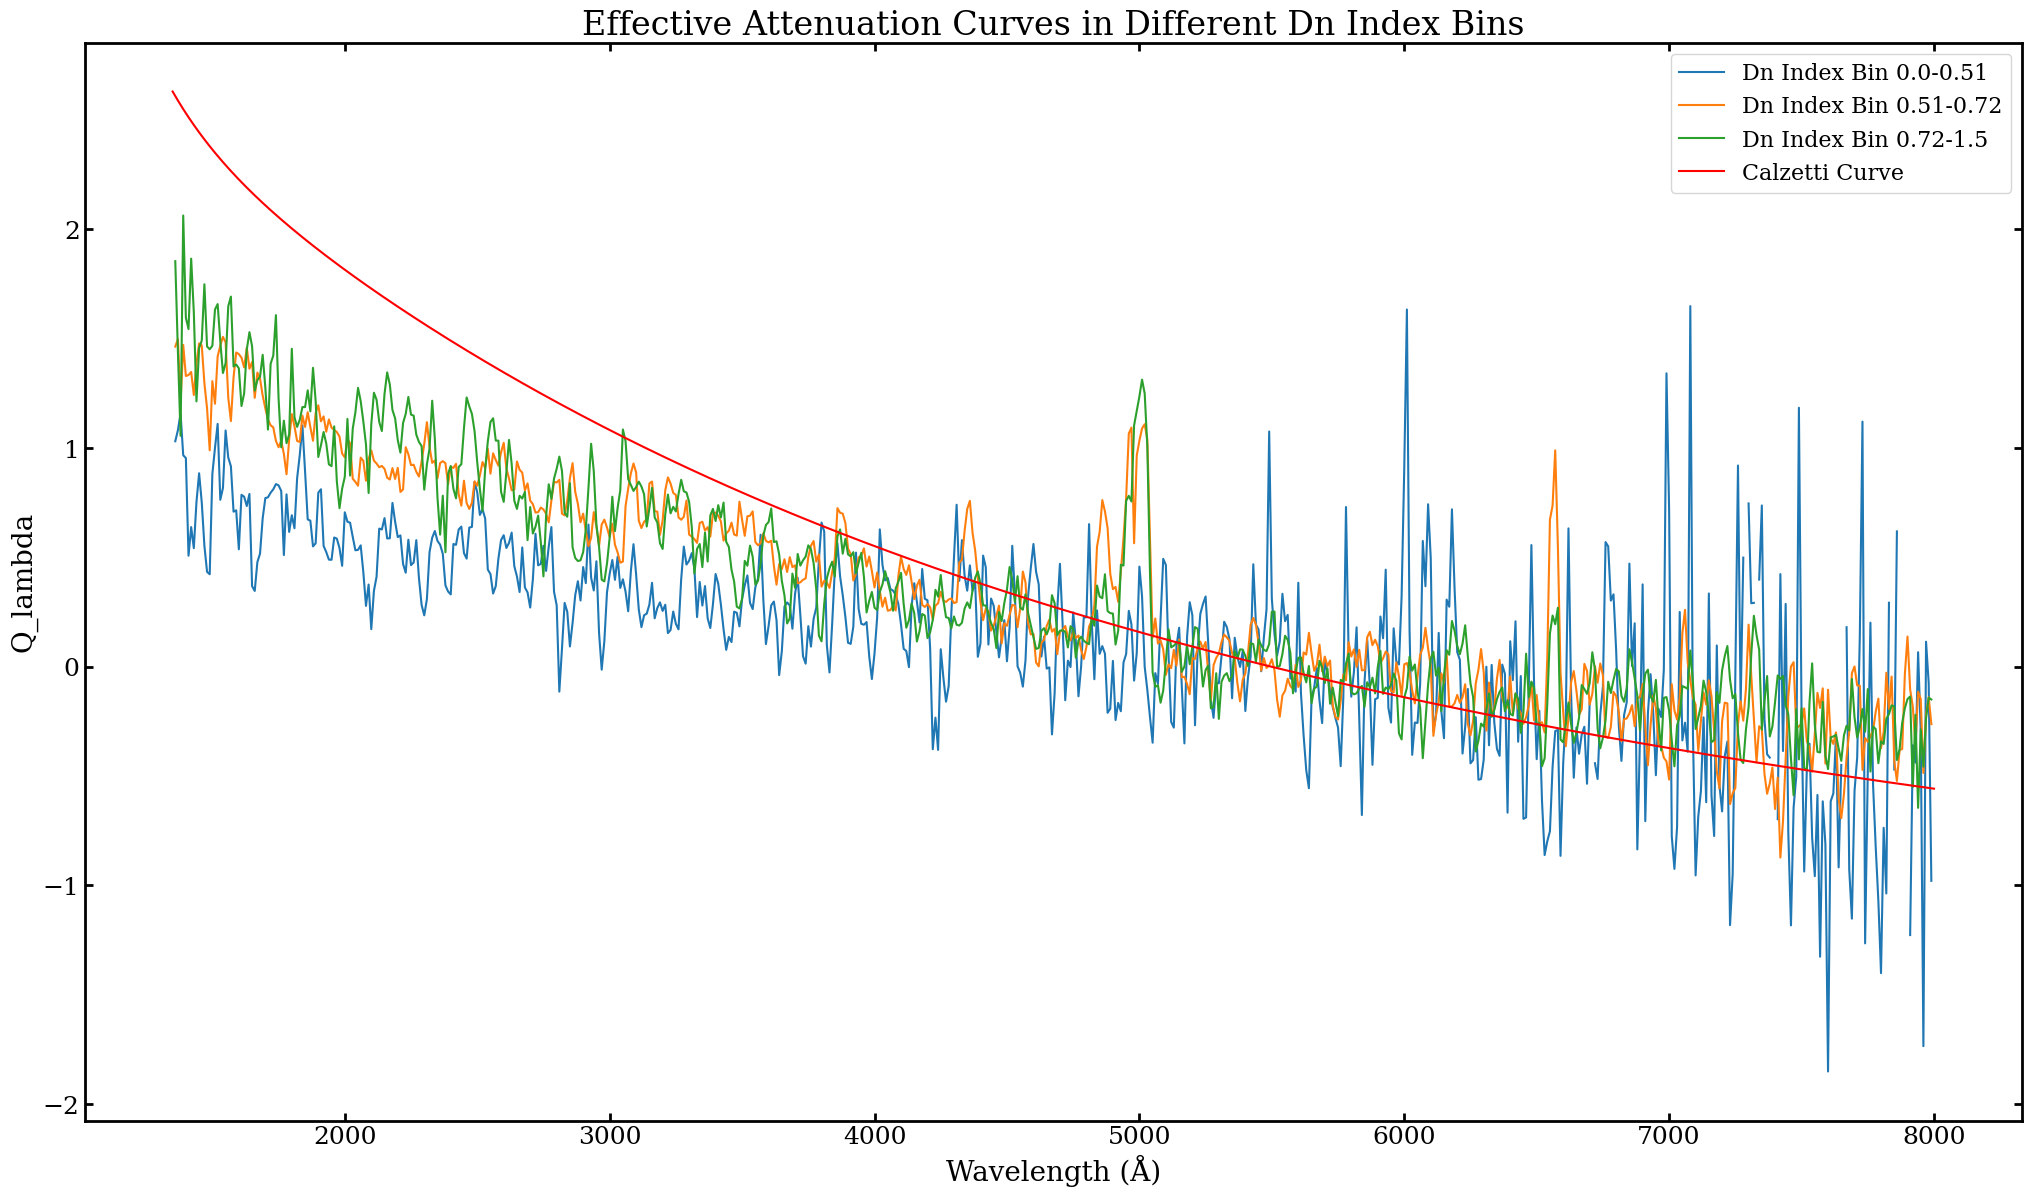

In [31]:
fig, ax=plt.subplots(figsize=(25,14))

for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve=effective_attenuation_curve_list[dn_bin_index]
    #smooth the effective_attenuation_curve with box kernel
    ax.plot(common_wavelength, effective_attenuation_curve, label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}', color=colors[dn_bin_index])

ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Dn Index Bins', fontsize=24)
plt.legend(fontsize=16)
plt.savefig('Dn_Index_Binned_Effective_Attenuation_Curves.pdf', bbox_inches='tight')
plt.show()

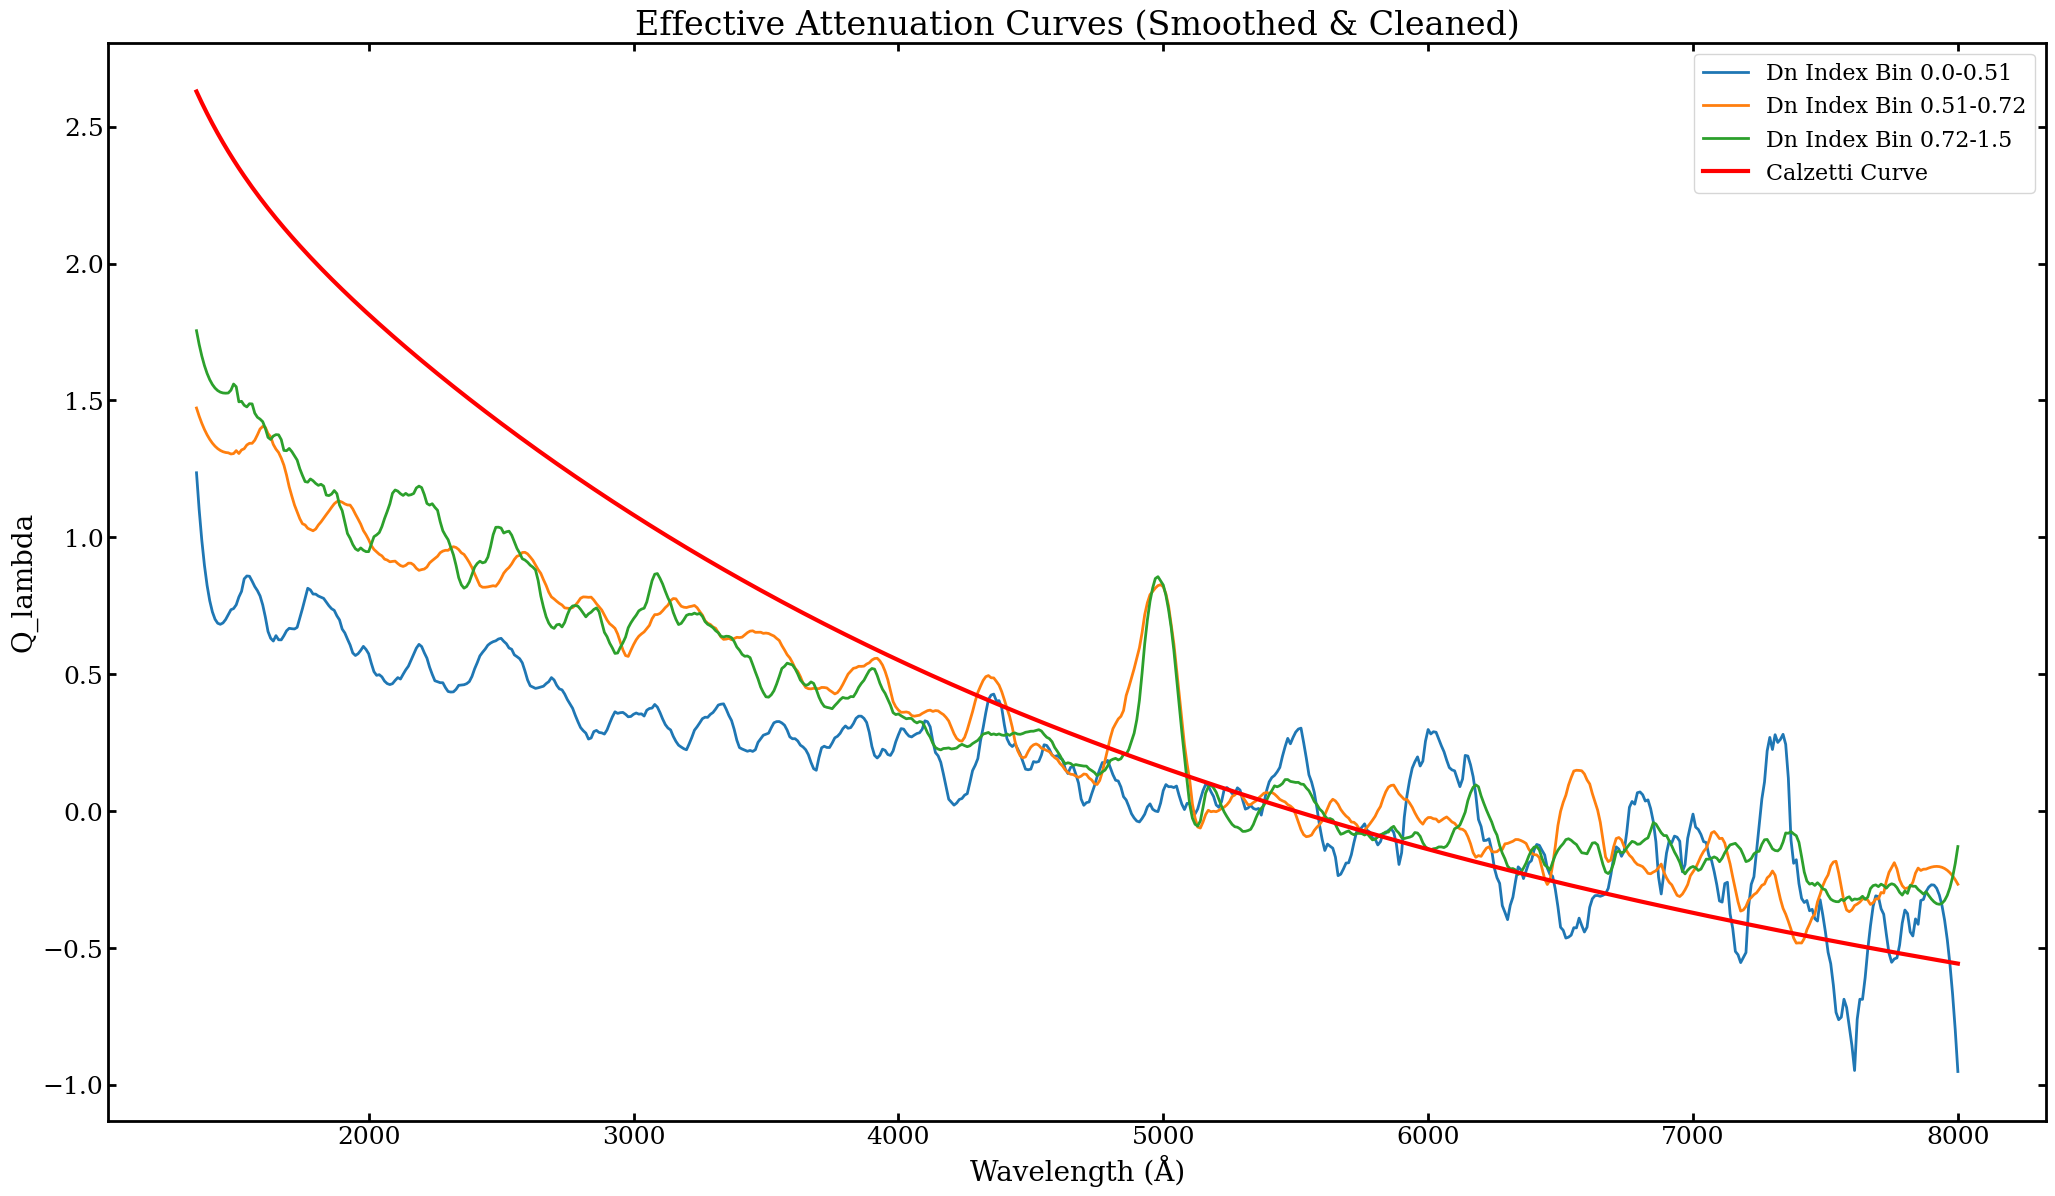

In [32]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import numpy as np
import pandas as pd  # 引入 pandas 用于处理 NaN

fig, ax = plt.subplots(figsize=(25, 14))

# 平滑参数
window_len = 25  # 窗口大小，根据需要调整
poly_order = 3   # 多项式阶数

for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve = effective_attenuation_curve_list[dn_bin_index]

    # --- 第一步：清洗数据 (去除 NaN/Inf) ---
    # 将 numpy 数组转换为 pandas Series，方便使用插值
    series_curve = pd.Series(effective_attenuation_curve)

    # 替换无穷大为 NaN，然后进行线性插值填补 NaN
    # limit_direction='both' 保证开头或结尾的 NaN 也能被填补
    curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')

    # 转回 numpy array
    curve_clean = curve_clean.to_numpy()

    # 检查：如果全都是 NaN (比如整条曲线都没数据)，则跳过
    if np.isnan(curve_clean).all():
        continue

    # --- 第二步：平滑数据 ---
    try:
        # 确保窗口长度不超过数据长度
        current_window_len = window_len
        if len(curve_clean) < window_len:
            # 如果数据太短，窗口长度必须小于数据长度，且必须是奇数
            current_window_len = len(curve_clean) if len(curve_clean) % 2 != 0 else len(curve_clean) - 1

        if current_window_len < poly_order + 2:
             # 数据实在太少，无法平滑，直接画原始数据
             smoothed_curve = curve_clean
        else:
             smoothed_curve = savgol_filter(curve_clean, window_length=current_window_len, polyorder=poly_order)

        # --- 第三步：绘图 ---
        ax.plot(common_wavelength, smoothed_curve,
                label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}',
                color=colors[dn_bin_index], linewidth=2)

    except Exception as e:
        print(f"Skipping bin {dn_bin_index} due to error: {e}")
        # 如果还是报错，画原始数据兜底
        ax.plot(common_wavelength, effective_attenuation_curve,
                label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]} (Raw)',
                color=colors[dn_bin_index], alpha=0.5)

# 绘制 Calzetti Curve
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve', linewidth=3)

plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves (Smoothed & Cleaned)', fontsize=24)
plt.legend(fontsize=16)
plt.savefig('Dn_Index_Binned_Effective_Attenuation_Curves_Smoothed_Labeled.pdf', bbox_inches='tight')
plt.show()

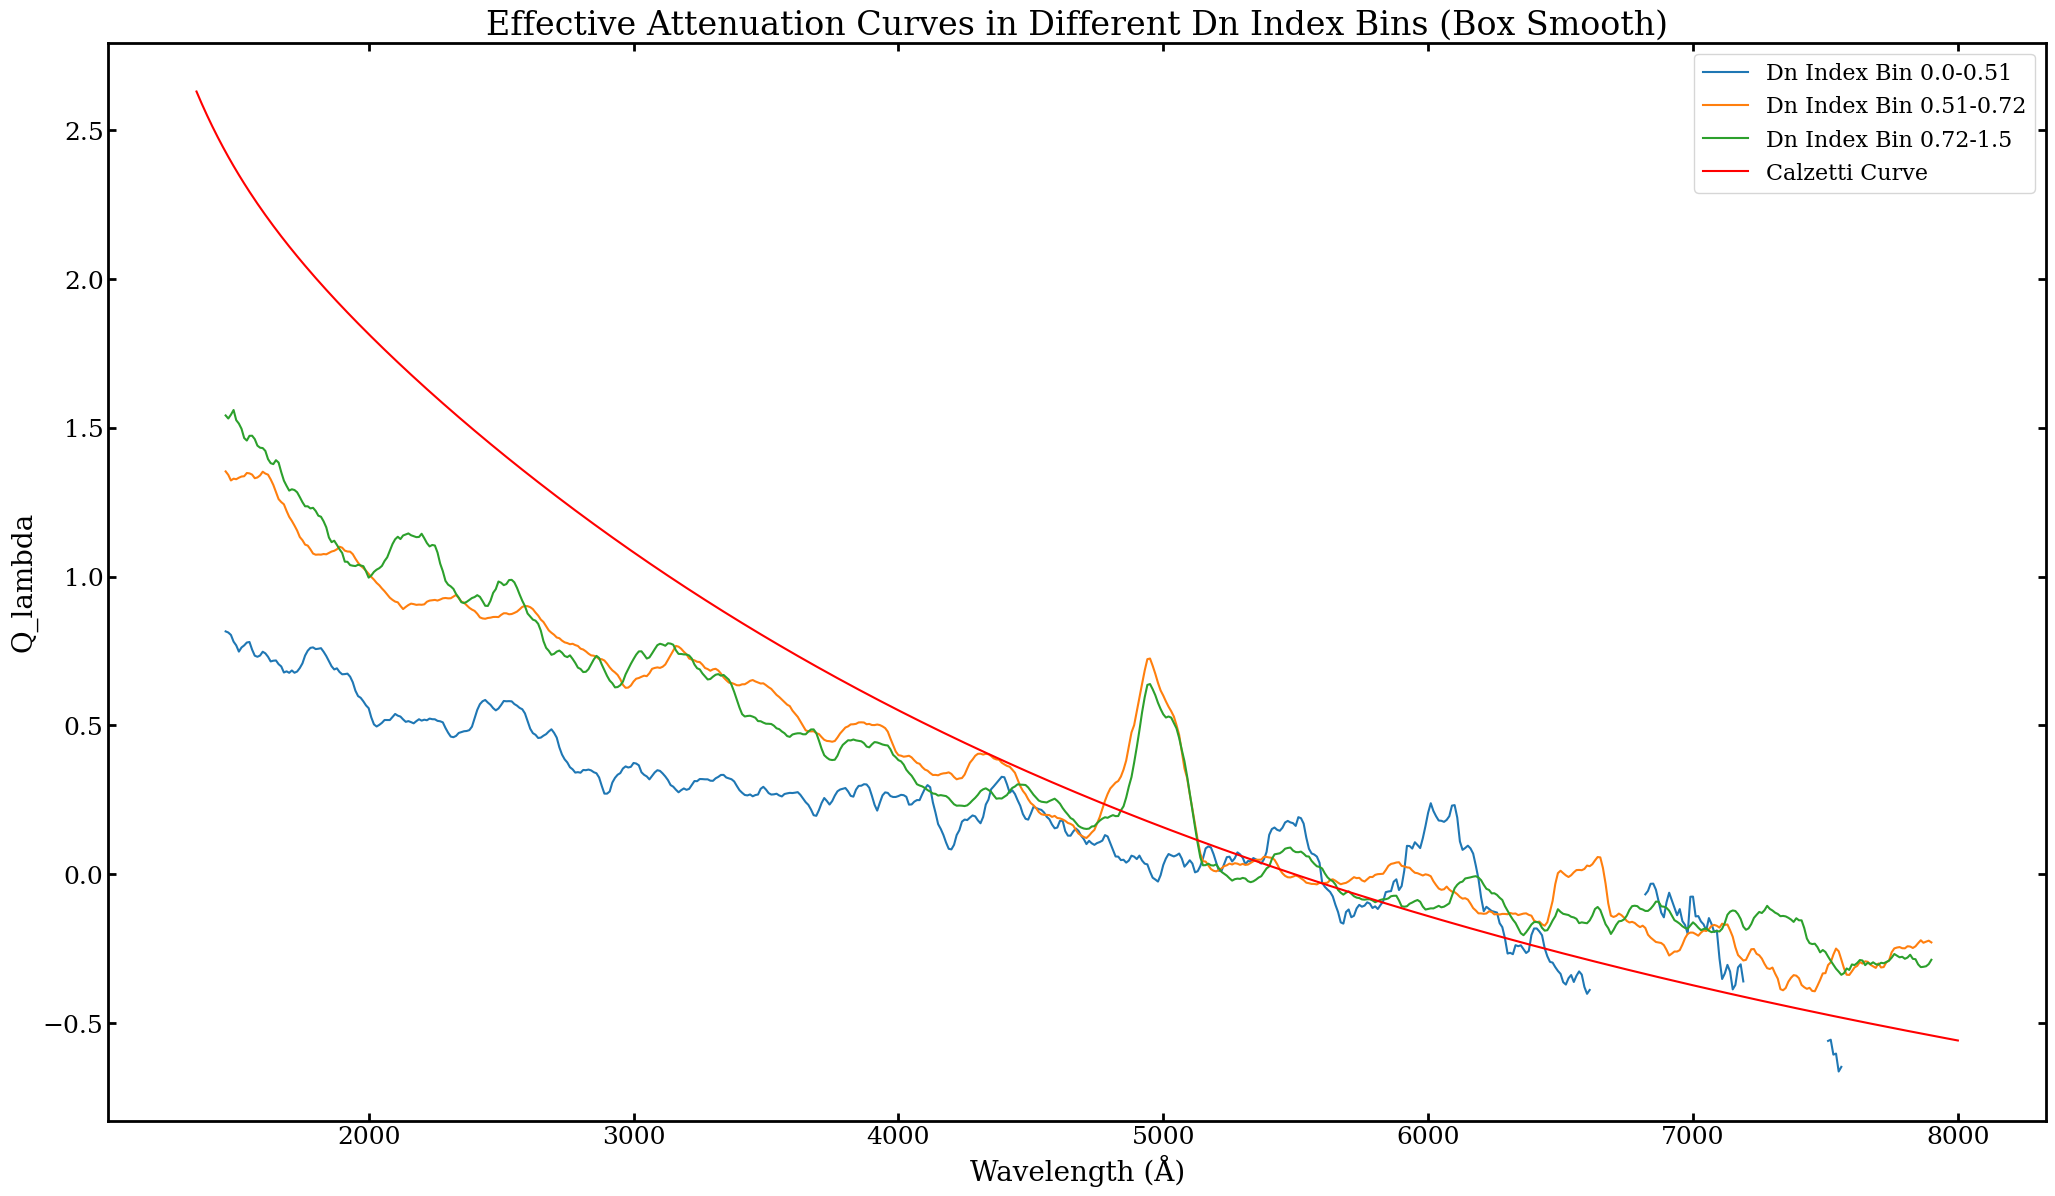

In [28]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 14))

# Box Kernel 大小 (窗口大小)
kernel_size = 20
kernel = np.ones(kernel_size) / kernel_size

for dn_bin_index in range(len(dn_index_conditions)):
    common_wavelength, effective_attenuation_curve = effective_attenuation_curve_list[dn_bin_index]

    # --- 核心修改：Box Kernel 平滑 ---
    # mode='same' 保证输出长度和输入一致，但边缘会有边界效应（可能突然下降）
    smoothed_curve = np.convolve(effective_attenuation_curve, kernel, mode='same')

    # 为了美观，通常把边缘受边界效应影响的数据设为 NaN，防止画出奇怪的尾巴
    smoothed_curve[:kernel_size//2] = np.nan
    smoothed_curve[-kernel_size//2:] = np.nan

    ax.plot(common_wavelength, smoothed_curve,
            label='Dn Index Bin '+f'{dn_index_conditions[dn_bin_index][0]}-{dn_index_conditions[dn_bin_index][1]}',
            color=colors[dn_bin_index])

ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')

plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curves in Different Dn Index Bins (Box Smooth)', fontsize=24)
plt.legend(fontsize=16)
plt.show()

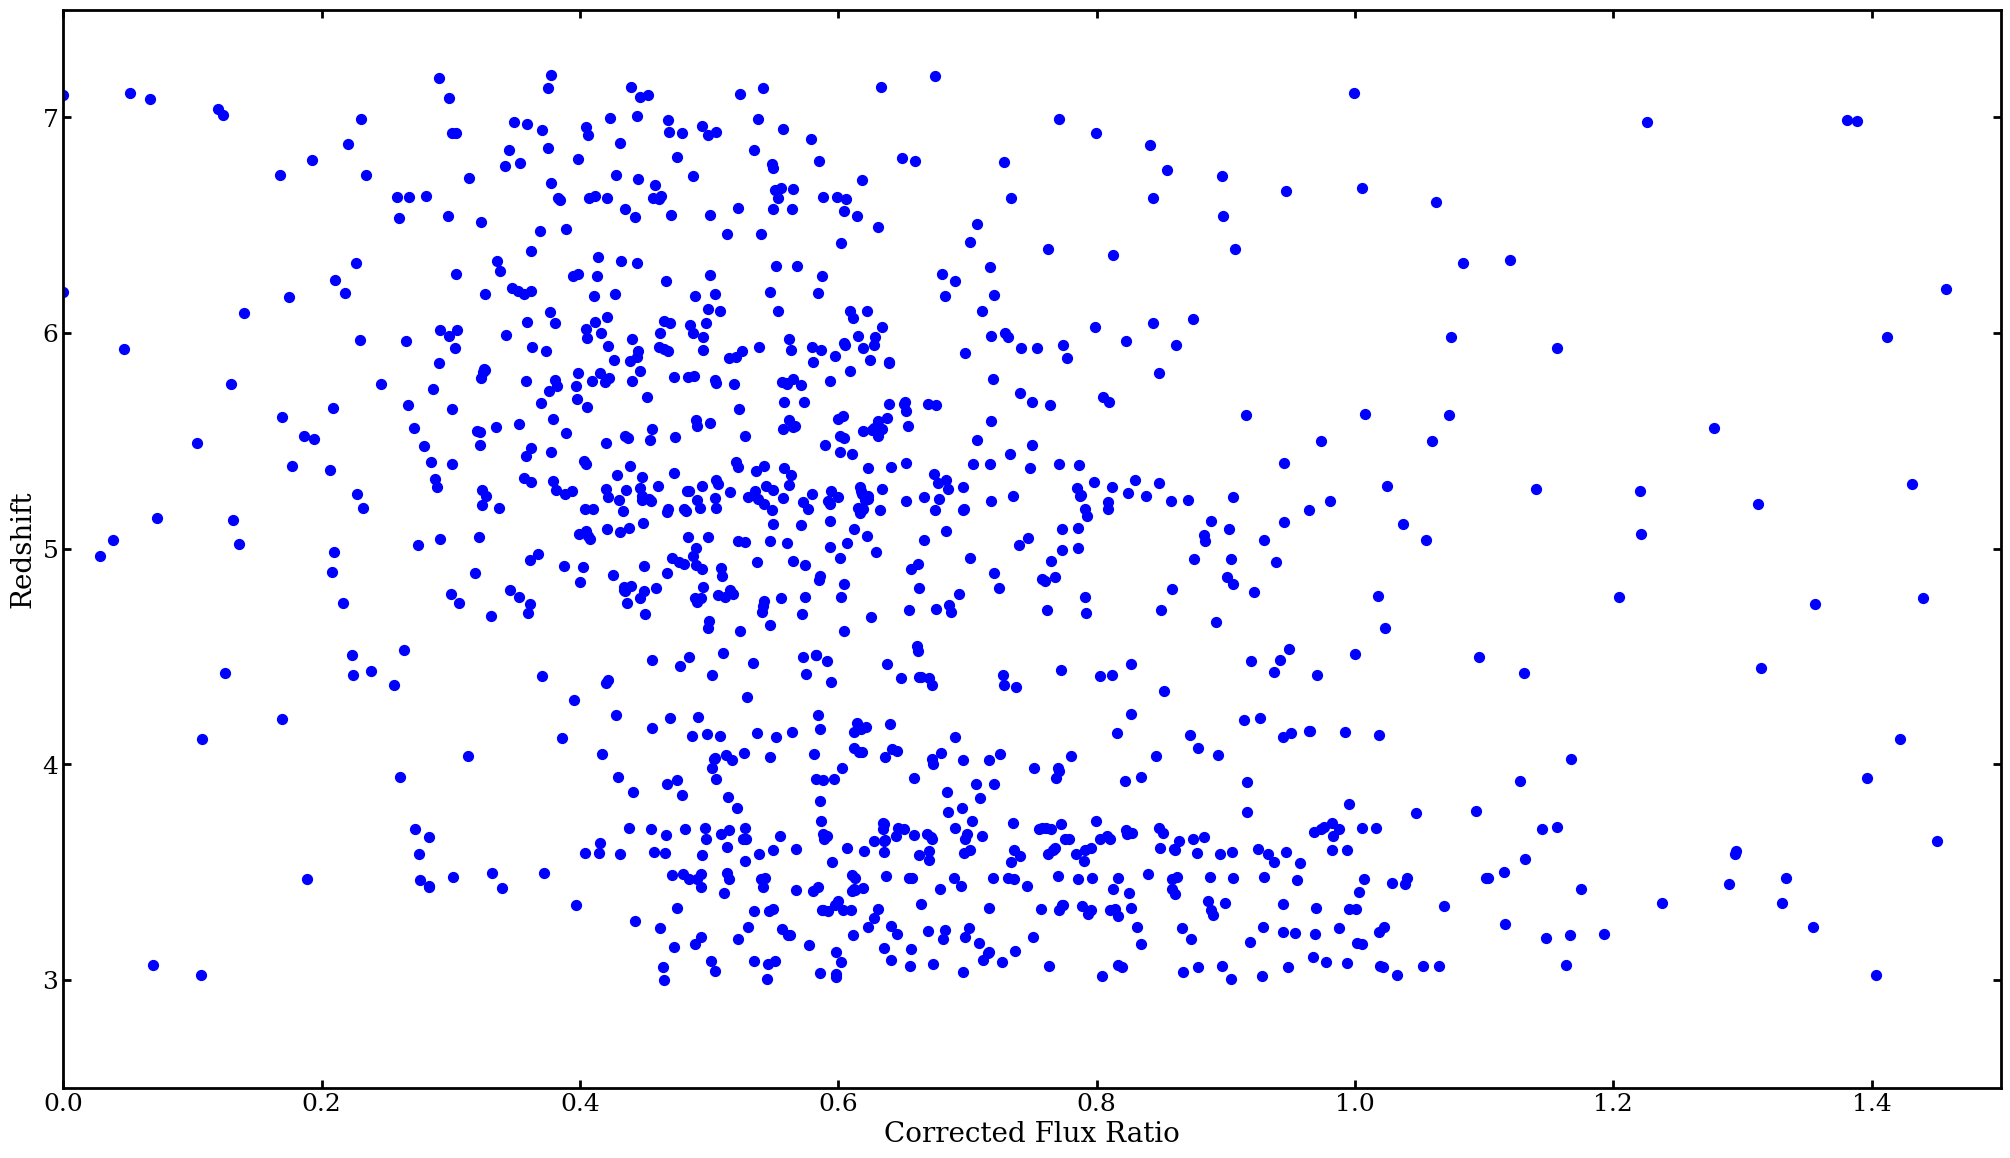

In [39]:
plt.scatter(Corrected_Flux_Ratio, redshift_list, color='blue', alpha=1,s=50)
plt.xlabel('Corrected Flux Ratio', fontsize=20)
plt.ylabel('Redshift', fontsize=20)
plt.xlim(0,1.5)
plt.ylim(2.5,7.5)
plt.savefig('Corrected_Flux_Ratio_vs_Redshift_Scatter.pdf', bbox_inches='tight')